------
<h3 style="color: mediumvioletred; text-align: center;">Name: Muhammad Sohaib</h3>
<h3 style="color: mediumvioletred; text-align: center;">Roll No: 22F-BSAI-40</h3>
<h3 style="color: mediumvioletred; text-align: center;">Course: Deep Learning</h3>
<h3 style="color: mediumvioletred; text-align: center;">Assignment: 01</h3>
<h3 style="color: mediumvioletred; text-align: center;">Topic: Complex Computing Problem</h3>
<h3 style="color: mediumvioletred; text-align: center;">Submitted to: Engr. Hamza Farooqui</h3>

---

<h4 style="color: palevioletred;">
“Can AI Save Lives?
</h4>

<h3 style="color: palevioletred;">
Building an Intelligent Clinical Early Warning System”
</h3>

-------

<h2 style="color: Aqua;">THE CHALLENGE</h2>

<p style="color: lightblue;">
Every year, thousands of patients in hospitals deteriorate silently, their vitals shift gradually, their clinical
notes grow more urgent, and yet the warning signs go unnoticed until it is too late. Hospitals are now
turning to AI to build Early Warning Systems that monitor patients continuously and flag those at risk of
sepsis, cardiac arrest, or ICU transfer before a crisis occurs.
You have been hired as a Machine Learning Engineer at a healthcare AI startup. Your team has been
given access to a real-world clinical dataset and tasked with building a deep learning pipeline that can
predict patient deterioration risk from a combination of time-series vital signs and free-text clinical notes.
Your models must be accurate but more importantly, your decisions must be explainable, because in
healthcare a doctor needs to understand why the model flagged a patient, not just that it did.</p>

-----------

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<h2 style="color: Aqua;">Importing Libraries</h2>


In [57]:
# =============================================================================
# BUILT-IN PYTHON LIBRARIES
# =============================================================================

import os                      # Operating system: files, directories, env variables
import warnings                # Warning control system
import time                    # Time tracking, delays, execution timing
import random                  # Random number generation for reproducibility
from tqdm import tqdm
warnings.filterwarnings("ignore")  # Disable warnings globally
from typing import Tuple, List

# =============================================================================
# NUMPY & PANDAS
# =============================================================================

import numpy as np            # Numerical computing (arrays, math operations)
import pandas as pd           # Data manipulation using DataFrames


# =============================================================================
# VISUALIZATION LIBRARIES
# =============================================================================

import matplotlib.pyplot as plt          # Plotting graphs and figures
import matplotlib.gridspec as gridspec   # Advanced subplot layouts
import seaborn as sns                    # Statistical visualization (built on matplotlib)


# =============================================================================
# SCIKIT-LEARN (PREPROCESSING + EVALUATION)
# =============================================================================

from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
# StandardScaler: normalize features
# LabelEncoder: encode categorical labels
# OneHotEncoder: convert categories into binary vectors

from sklearn.impute import SimpleImputer # Handle missing values

# Evaluation metrics for classification models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

from sklearn.pipeline import Pipeline
# Chain multiple preprocessing + model steps

from sklearn.compose import ColumnTransformer
# Apply transformations to specific columns

from sklearn.utils import resample
# Handle imbalanced datasets

from sklearn.utils.class_weight import compute_class_weight
# Compute class weights for imbalance handling

# =============================================================================
# PYTORCH (DEEP LEARNING)
# =============================================================================

import torch                  # Core PyTorch library (tensors + GPU support)

import torch.nn as nn         # Neural network layers & loss functions

from torch.utils.data import Dataset, DataLoader, TensorDataset
# Dataset: custom dataset class
# DataLoader: batch loading utility
# TensorDataset: wrap tensors into dataset format
import torch.optim as optim
from collections import defaultdict
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import AdamW  # AdamW optimizer for deep learning models

# Device configuration (IMPORTANT: GPU/CPU selection)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
try:
    import torch
    from torch.utils.data import Dataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    # Optional: If Dataset is needed as a placeholder when torch is missing
    Dataset = object

# =============================================================================
# TENSORFLOW / KERAS
# =============================================================================

import tensorflow as tf       # Core TensorFlow library

from tensorflow.keras.optimizers import Adam, SGD
# Optimizers for neural network training

from tensorflow.keras.models import Sequential
# Sequential model API

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
# Common neural network layers

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# Training callbacks (stop early, reduce LR, save best model)

from tensorflow import keras
# High-level Keras API

from tensorflow.keras import layers
# Additional Keras layers module

from typing  import List, Dict, Tuple

import torch
import torch.nn            as nn
from torch.utils.data      import Dataset, DataLoader
from torch.optim           import AdamW
from torch.cuda.amp        import autocast, GradScaler

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (
    accuracy_score, precision_score,
    recall_score,  f1_score,
    classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore")

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# =============================================================================
# TRANSFORMERS (NLP MODELS)
# =============================================================================

from transformers import (
    AutoModel,
    AutoTokenizer,                     # Generic tokenizer loader
    AutoModelForSequenceClassification,# Classification transformer model
    BertForSequenceClassification,     # BERT classifier
    BertTokenizer,                     # BERT tokenizer
    get_linear_schedule_with_warmup    # Learning rate scheduler
)
from torch.amp import GradScaler

from torch.optim import AdamW
# (duplicate avoided earlier conceptually — kept single import usage above)

# =============================================================================
# REPRODUCIBILITY (SEEDS)
# =============================================================================
SEED = 42
random.seed(SEED)        # Python
np.random.seed(SEED)     # NumPy
torch.manual_seed(SEED)  # PyTorch
tf.random.set_seed(SEED) # TensorFlow


# =============================================================================
# VISUALIZATION CONFIG (THEME + PALETTE)
# =============================================================================
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.alpha':       0.8,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PALETTE = {
    'lstm':   '#3b82f6',
    'gru':    '#10b981',
    'bilstm': '#f59e0b',
    'accent': '#ef4444',
}
# Color palette for consistent model visualization

cuda


----

<h1 style="color: Aqua; text-align: center;">Generation 1 — Establishing the Baseline</h1>

<p style="color: lightblue; text-align: center;">"Before we trust AI with patient lives, we need to know what a simple model can and cannot do."</p>

----



<h1 style="color: skyblue;">SECTION 1.0 — Dataset Loading </h1>
<h2 style="color: lightblue;">PhysioNet Sepsis Challenge 2019 Dataset </h2>

<p style="color: lightblue; text-align: center;">The PhysioNet Sepsis 2019 dataset contains hourly ICU records per patient with 40 clinical features and a binary `SepsisLabel` target. We load the pre-merged flat CSV (all patients concatenated) that you already have.</p>



In [58]:
print("Loading Data...")
df1 = pd.read_csv('/content/drive/MyDrive/Intelligent Clinical Early Warning System/Dataset.csv')

Loading Data...


In [59]:
print(f" Dataset shape  : {df1.shape}")
print(f" Unique patients: {df1['Patient_ID'].nunique():,}")
print(f" Total hours    : {len(df1):,}")
print("─" * 60)
print("\nFirst 5 rows:")
pd.set_option('display.max_columns', None)  # Ensure all columns are displayed
display(df1.head())

 Dataset shape  : (1552210, 44)
 Unique patients: 40,336
 Total hours    : 1,552,210
────────────────────────────────────────────────────────────

First 5 rows:


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,26.0,0.4,NaN,NaN,NaN,NaN,23.0,NaN,9.6,104.0,0.8,NaN,161.0,NaN,1.6,2.1,3.2,NaN,NaN,29.7,9.5,30.6,11.3,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


<h1 style="color: skyblue;">SECTION 1.1 — Data Preprocessing</h1>



<div style="color: lightblue">
    <h3 style="text-align: left;">Clinical Data Preprocessing Pipeline</h3>
    <ol style="padding-left: 20px;">
        <li style="margin-bottom: 8px;">Select clinical feature columns (drop IDs, meta columns).</li>
        <li style="margin-bottom: 8px;">Patient-level forward-fill then backward-fill to carry vitals across hours.</li>
        <li style="margin-bottom: 8px;">Global median imputation for remaining NaNs.</li>
        <li style="margin-bottom: 8px;">Feature engineering using rolling statistics and lag features.</li>
        <li style="margin-bottom: 8px;">StandardScaler normalization.</li>
        <li style="margin-bottom: 8px;">Stratified, patient-wise Train / Validation / Test split to prevent data leakage.</li>
    </ol>
</div>



In [60]:
# Drop empty/garbage columns and define target
if 'Unnamed: 0' in df1.columns:
    df1 = df1.drop(columns=['Unnamed: 0'])

# Patient_ID column is currently the last column, we will move it to the first position for better readability and analysis
col = df1.pop("Patient_ID")
df1.insert(0, "Patient_ID", col)

In [61]:
print(f"Dataset shape: {df1.shape}")
print("First 5 rows of the dataset:")
pd.set_option('display.max_columns', None)  # Ensure all columns are displayed
display(df1.head())

Dataset shape: (1552210, 43)
First 5 rows of the dataset:


,Patient_ID,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,17072,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0
1,17072,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0
2,17072,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0
3,17072,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0
4,17072,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,26.0,0.4,NaN,NaN,NaN,NaN,23.0,NaN,9.6,104.0,0.8,NaN,161.0,NaN,1.6,2.1,3.2,NaN,NaN,29.7,9.5,30.6,11.3,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0


In [62]:
# missing values percentage
missing_percentage = (df1.isnull().sum() / len(df1)) * 100
print("Percentage of missing values in each column:")
missing_percentage

Percentage of missing values in each column:


,0
Patient_ID,0.000000
Hour,0.000000
HR,9.882619
O2Sat,13.061119
Temp,66.162697
SBP,14.576958
MAP,12.451279
DBP,31.345887
Resp,15.354559
EtCO2,96.286843


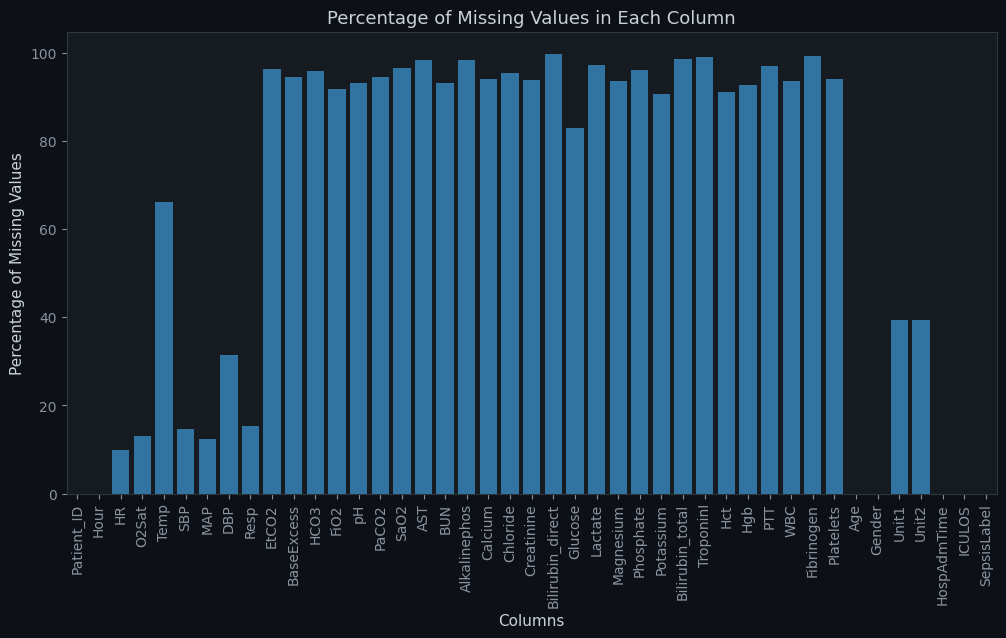

In [63]:
# check distribution of missing values of each column
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
plt.xticks(rotation=90)
plt.title("Percentage of Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values")
plt.show()

In [64]:
numeric_features = df1.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df1.select_dtypes(include=['object', 'category']).columns

# print numeric and categorical features
print(f"Numeric features: {numeric_features.tolist()}")
print(f"Categorical features: {categorical_features.tolist()}")

Numeric features: ['Patient_ID', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']
Categorical features: []


In [65]:
# Drop columns with >95% missing values
missing_pct = df1.isnull().mean() * 100
high_missing_cols = missing_pct[missing_pct > 95].index.tolist()

# Never drop target
if "SepsisLabel" in high_missing_cols:
    high_missing_cols.remove("SepsisLabel")
df1 = df1.drop(columns=high_missing_cols)
print(f"Dropped {len(high_missing_cols)} columns:")
print(high_missing_cols)

# Impute remaining missing values
num_cols = df1.select_dtypes(include=['number']).columns.tolist()
for col in num_cols:
    df1[col] = df1[col].fillna(df1[col].median())

# Save cleaned dataset
cleaned_path = "/content/drive/MyDrive/Intelligent Clinical Early Warning System/cleaned_sepsis_data.csv"
df1.to_csv(cleaned_path, index=False)
print("\n✓ Cleaned dataset saved")

# Balance classes (1:1)
majority = df1[df1["SepsisLabel"] == 0]
minority = df1[df1["SepsisLabel"] == 1]

majority_down = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

df1 = pd.concat([majority_down, minority]).sample(
    frac=1,
    random_state=42
)
# Save balanced dataset
balanced_path = "/content/drive/MyDrive/Intelligent Clinical Early Warning System/balanced_sepsis_data.csv"
df1.to_csv(balanced_path, index=False)
print("✓ Balanced dataset saved")

# Features / Target
target = "SepsisLabel"
drop_cols = ["Patient_ID", target]

cat_cols = [c for c in ["Gender", "Unit1", "Unit2"]
            if c in df1.columns]
X = df1.drop(columns=drop_cols)
y = df1[target]
num_cols = [c for c in X.columns if c not in cat_cols]

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", "passthrough", cat_cols)
])

X_processed = preprocessor.fit_transform(X)
print("\nProcessed Shape:", X_processed.shape)

Dropped 13 columns:
['EtCO2', 'HCO3', 'SaO2', 'AST', 'Alkalinephos', 'Chloride', 'Bilirubin_direct', 'Lactate', 'Phosphate', 'Bilirubin_total', 'TroponinI', 'PTT', 'Fibrinogen']

✓ Cleaned dataset saved
✓ Balanced dataset saved

Processed Shape: (55832, 28)



SepsisLabel distribution:
  Non-Sepsis (0): 27,916  (50.00%)
  Sepsis     (1): 27,916  (50.00%)
  Imbalance ratio: 1.0:1


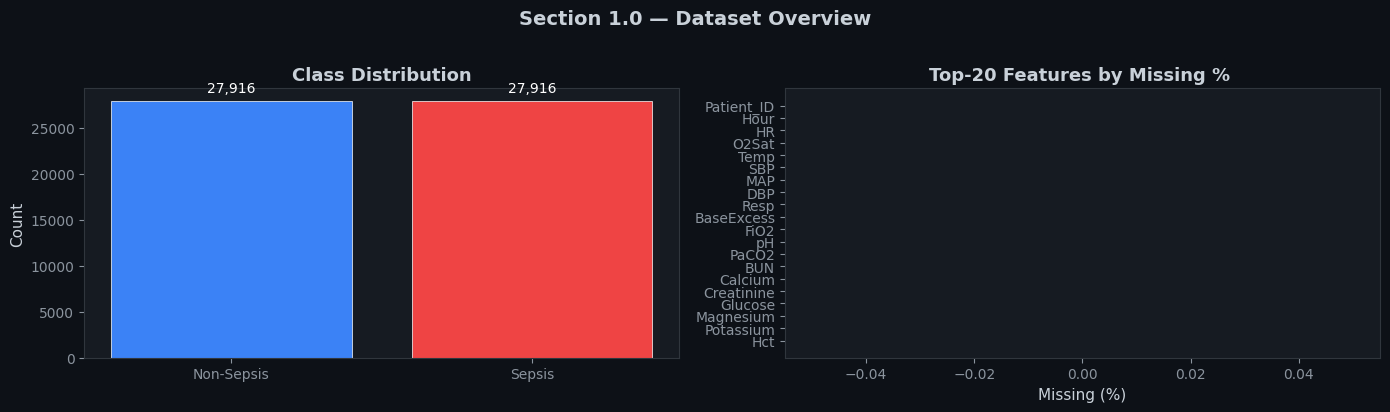

'/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_1_0_new_overview.png


In [66]:
# ── Class distribution ────────────────────────────────────────────────────────
label_counts = df1['SepsisLabel'].value_counts()
sepsis_pct   = label_counts[1] / len(df1) * 100

print(f"\nSepsisLabel distribution:")
print(f"  Non-Sepsis (0): {label_counts[0]:,}  ({100 - sepsis_pct:.2f}%)")
print(f"  Sepsis     (1): {label_counts[1]:,}  ({sepsis_pct:.2f}%)")
print(f"  Imbalance ratio: {label_counts[0]/label_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
colors = ['#3b82f6', '#ef4444']
axes[0].bar(['Non-Sepsis', 'Sepsis'], label_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10, color='white')

# Missing data heatmap
miss_pct = (df1.isnull().sum() / len(df1) * 100).sort_values(ascending=False).head(20)
axes[1].barh(miss_pct.index, miss_pct.values, color='#f59e0b')
axes[1].set_title('Top-20 Features by Missing % ', fontweight='bold')
axes[1].set_xlabel('Missing (%)')
axes[1].invert_yaxis()

plt.suptitle('Section 1.0 — Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_1_0_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("'/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_1_0_new_overview.png")

In [67]:
# Stratified Split to maintain mortality ratio
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)


In [68]:
# display shapes of processed data
print("Processed training features shape:", X_train.shape)
print("Processed testing features shape:", y_train.shape)
print("Processed training labels shape:", X_test.shape)
print("Processed testing labels shape:", y_test.shape)

Processed training features shape: (44665, 28)
Processed testing features shape: (44665,)
Processed training labels shape: (11167, 28)
Processed testing labels shape: (11167,)


<h1 style="color: skyblue;">SECTION 1.2 — Helper Utilities</h1>
<p style="color: lightblue;">Shared functions for model evaluation, curve plotting, and metrics tables used across all three generations.</p>


In [69]:
THRESHOLD = 0.35   # Lower threshold → higher Recall (critical for sepsis)
                   # NOTE: In a life-critical setting, a FALSE NEGATIVE (missing
                   # sepsis) costs a patient's life. A FALSE POSITIVE merely
                   # triggers unnecessary but safe clinical review. Therefore
                   # we deliberately lower the decision threshold to maximise
                   # Recall even at the cost of some Precision.

def evaluate_model(model, X, y_true, name='Model', threshold=THRESHOLD):
    """Return classification metrics dict and print a report."""
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n{'─'*55}")
    print(f" {name} — Evaluation Report (threshold={threshold})")
    print(f"{'─'*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}   ← Most critical metric for sepsis detection")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"{'─'*55}")

    return {
        'name': name, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc,
        'y_prob': y_prob, 'y_pred': y_pred
    }


def plot_training_history(histories, labels, title='Loss & Accuracy Curves'):
    """Side-by-side loss and accuracy plots for multiple training runs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#3b82f6', '#ef4444', '#10b981', '#f59e0b']

    for i, (hist, label) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        epochs = range(1, len(hist.history['loss']) + 1)
        # Loss
        axes[0].plot(epochs, hist.history['loss'],     color=c,  lw=2,   label=f'{label} train')
        axes[0].plot(epochs, hist.history['val_loss'], color=c,  lw=2,   label=f'{label} val',
                     linestyle='--')
        # Accuracy
        axes[1].plot(epochs, hist.history['accuracy'],     color=c, lw=2, label=f'{label} train')
        axes[1].plot(epochs, hist.history['val_accuracy'], color=c, lw=2, label=f'{label} val',
                     linestyle='--')

    for ax, metric in zip(axes, ['Loss (Binary Cross-Entropy)', 'Accuracy']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Sepsis', 'Sepsis'],
                yticklabels=['Non-Sepsis', 'Sepsis'],
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    return fig


def plot_roc_curves(results, title='ROC Curves'):
    colors = ['#3b82f6', '#ef4444', '#10b981']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], 'w--', lw=1, label='Random baseline')
    for res, c in zip(results, colors):
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, color=c, lw=2,
                label=f"{res['name']}  (AUC={res['auc']:.3f})")
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


print("✅ Helper utilities defined.")

✅ Helper utilities defined.



<h1 style="color: skyblue;">SECTION 1.3 —  Optimizer Comparison: Adam vs SGD</h1>

<p style="color: lightblue;">
We train a **shallow feedforward DNN** (3 hidden layers) twice — once with **Adam** and once with **SGD** — to understand the impact of optimizer choice before adding any regularization. Both use identical architecture and hyperparameters.

**Why Recall matters most here:**
> A *false negative* (predicting "no sepsis" when sepsis is present) means no intervention is triggered for a deteriorating patient. This directly costs lives. A *false positive* (flagging a healthy patient) causes unnecessary but clinically safe review. In any life-critical AI system, **Recall must be prioritised** over Precision.
</p>

In [70]:
INPUT_DIM = X_train.shape[1]
def build_baseline_dnn(optimizer, name="DNN_Baseline"):
    inp = tf.keras.Input(
        shape=(INPUT_DIM,),
        name="clinical_features")

    x = tf.keras.layers.Dense(
        256,
        activation="relu")(inp)

    x = tf.keras.layers.Dense(
        128,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dense(
        64,
        activation="relu"
    )(x)

    out = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs=inp,
        outputs=out,
        name=name
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [71]:
# ─────────────────────────────────────────────────────────────
# Training Function
# ─────────────────────────────────────────────────────────────

from time import time

CALLBACKS = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

EPOCHS = 60
BATCH_SIZE = 2048
def train_dnn(optimizer, optimizer_name):

    print(f"\n{'='*60}")
    print(f"Training DNN with {optimizer_name}")
    print(f"{'='*60}")

    model = build_baseline_dnn(
        optimizer,
        name=f"DNN_{optimizer_name}"
    )

    start_time = time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=CALLBACKS,
        verbose=1
    )

    training_time = time() - start_time

    return model, history, training_time

In [72]:
# ─────────────────────────────────────────────────────────────
# Optimizer Comparison
# ─────────────────────────────────────────────────────────────

optimizers = {

    "Adam":
        tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),

    "SGD":
        tf.keras.optimizers.SGD(
            learning_rate=0.01,
            momentum=0.9,
            nesterov=True
        )
}
trained_models = {}
training_histories = {}
training_times = {}

for name, optimizer in optimizers.items():

    model, history, train_time = train_dnn(
        optimizer,
        name
    )

    trained_models[name] = model
    training_histories[name] = history
    training_times[name] = train_time

print("\n✅ All optimizers completed.")


Training DNN with Adam
Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.6693 - loss: 0.6210 - val_accuracy: 0.6848 - val_loss: 0.6005 - learning_rate: 0.0010
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6945 - loss: 0.5936 - val_accuracy: 0.6917 - val_loss: 0.5940 - learning_rate: 0.0010
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7020 - loss: 0.5839 - val_accuracy: 0.6965 - val_loss: 0.5876 - learning_rate: 0.0010
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7092 - loss: 0.5737 - val_accuracy: 0.7001 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7150 - loss: 0.5637 - val_accuracy: 0.6990 - val_loss: 0.5761 - learning_rate: 0.0010
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7207 - loss: 0.5556 - val_accuracy: 0.7009 - val_loss: 0.5736 - learning_rate: 0.0010
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7243 -

In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1.3 — Optimizer Comparison (Adam vs SGD)
# ─────────────────────────────────────────────────────────────────────────────

INPUT_DIM = X_train.shape[1]

def build_baseline_dnn(optimizer, name='Baseline'):
    """
    Shallow feedforward DNN — baseline model.
    Architecture: Input → 256 → 128 → 64 → 1 (sigmoid)
    Same architecture for fair optimizer comparison.
    """
    inp = keras.Input(shape=(INPUT_DIM,), name='clinical_features')

    x = layers.Dense(256, activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inp, outputs=out, name=name)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model
# ── Callbacks ────────────────────────────────────────────────────────────────
CALLBACKS = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        verbose=1
    )
]

EPOCHS   = 60
BATCH_SZ = 2048
# ─────────────────────────────────────────────────────────────
# Train with Adam
# ─────────────────────────────────────────────────────────────
print("▶ Training with Adam optimizer...")

adam_opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_adam = build_baseline_dnn(adam_opt, name='Baseline_Adam')

hist_adam = model_adam.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SZ,
    # class_weight=CLASS_WEIGHT,
    callbacks=CALLBACKS,
    verbose=1
)
# ─────────────────────────────────────────────────────────────
# Train with SGD
# ─────────────────────────────────────────────────────────────
print("\n▶ Training with SGD optimizer...")

sgd_opt = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

model_sgd = build_baseline_dnn(sgd_opt, name='Baseline_SGD')

hist_sgd = model_sgd.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SZ,
    # class_weight=CLASS_WEIGHT,
    callbacks=CALLBACKS,
    verbose=1
)

print("\n✅ Both optimizers trained.")

▶ Training with Adam optimizer...
Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.6263 - loss: 0.6430 - val_accuracy: 0.6796 - val_loss: 0.6077 - learning_rate: 0.0010
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6890 - loss: 0.6011 - val_accuracy: 0.6877 - val_loss: 0.5971 - learning_rate: 0.0010
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6977 - loss: 0.5899 - val_accuracy: 0.6916 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7026 - loss: 0.5817 - val_accuracy: 0.6974 - val_loss: 0.5859 - learning_rate: 0.0010
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7093 - loss: 0.5727 - val_accuracy: 0.6971 - val_loss: 0.5800 - learning_rate: 0.0010
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7139 - loss: 0.5639 - val_accuracy: 0.6983 - val_loss: 0.5753 - learning_rate: 0.0010
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 

In [74]:
optimizer_results = []

for name, model in trained_models.items():

    y_prob = model.predict(
        X_test,
        verbose=0
    )

    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    optimizer_results.append({
        "Optimizer": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Training Time (s)": training_times[name]
    })

optimizer_df = pd.DataFrame(optimizer_results)
optimizer_df.sort_values(
    by="F1-Score",
    ascending=False,
    inplace=True
)

optimizer_df

,Optimizer,Accuracy,Precision,Recall,F1-Score,Training Time (s)
0,Adam,0.703680,0.727491,0.651263,0.687270,10.652791
1,SGD,0.665264,0.691589,0.596454,0.640508,4.067644


In [75]:
best_optimizer = optimizer_df.iloc[0]["Optimizer"]

print("Best Optimizer:", best_optimizer)

best_dnn_model = trained_models[best_optimizer]

Best Optimizer: Adam


In [76]:
best_dnn = optimizer_df.iloc[0]
final_results = pd.DataFrame([
    {
        "Model": "DNN (Baseline)",
        "Accuracy": best_dnn["Accuracy"],
        "Precision": best_dnn["Precision"],
        "Recall": best_dnn["Recall"],
        "F1-Score": best_dnn["F1-Score"],
        "Training Time": best_dnn["Training Time (s)"]
    }
])

final_results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time
0,DNN (Baseline),0.70368,0.727491,0.651263,0.68727,10.652791


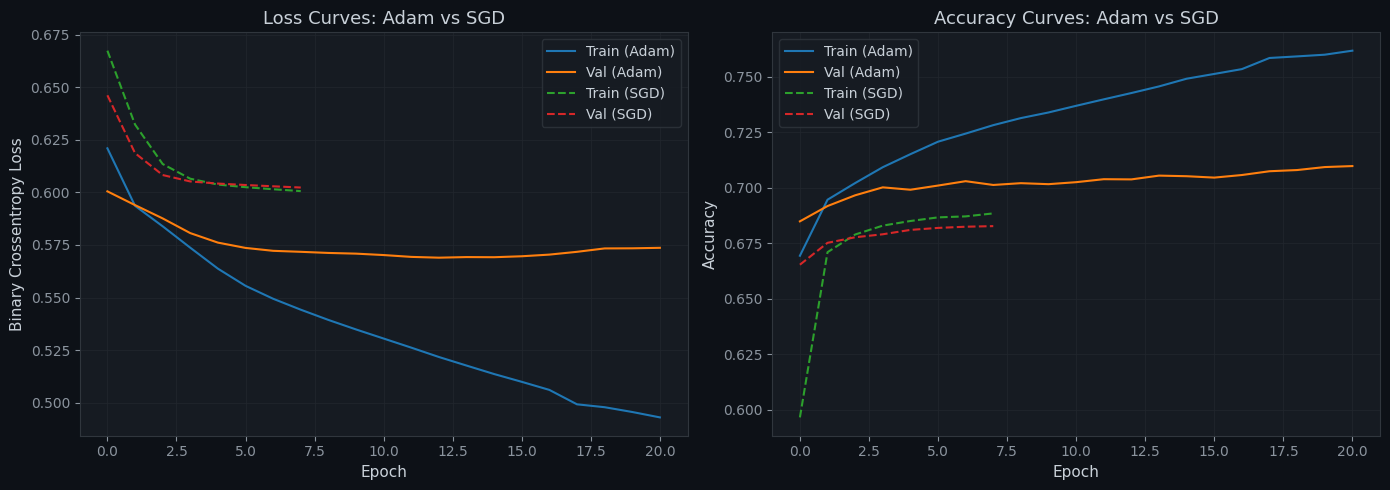

In [77]:
training_histories["Adam"]
training_histories["SGD"]

# Optimizer Comparison Plots
adam_hist = training_histories["Adam"]
sgd_hist  = training_histories["SGD"]

plt.figure(figsize=(14, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(adam_hist.history["loss"],label="Train (Adam)")
plt.plot(adam_hist.history["val_loss"],label="Val (Adam)")
plt.plot(sgd_hist.history["loss"],"--",label="Train (SGD)")
plt.plot(sgd_hist.history["val_loss"],"--",label="Val (SGD)")

plt.title("Loss Curves: Adam vs SGD")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(True)

# Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(adam_hist.history["accuracy"],label="Train (Adam)")
plt.plot(adam_hist.history["val_accuracy"],label="Val (Adam)")
plt.plot(sgd_hist.history["accuracy"],"--",label="Train (SGD)")
plt.plot(sgd_hist.history["val_accuracy"],"--",label="Val (SGD)")

plt.title("Accuracy Curves: Adam vs SGD")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/optimizer_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

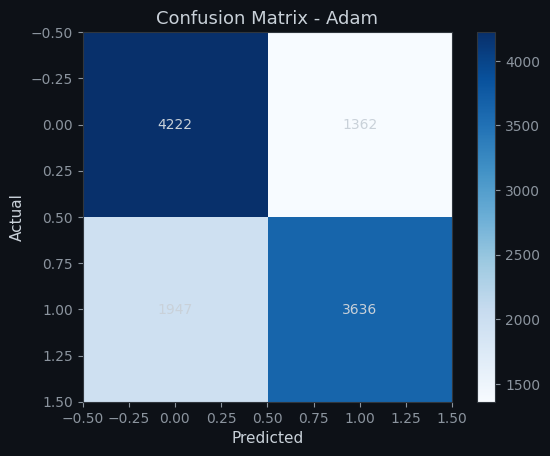

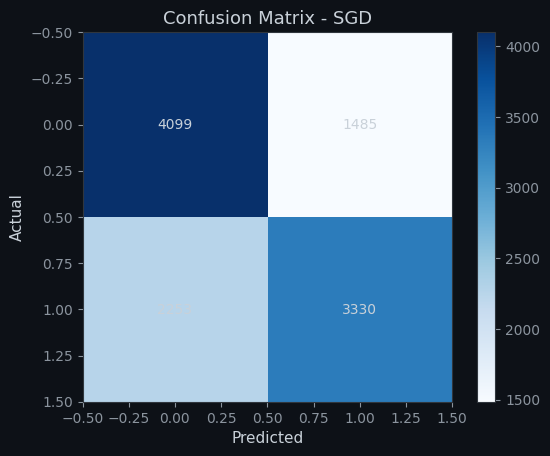

In [78]:
for name,model in trained_models.items():
    y_pred=(model.predict(X_test,verbose=0)>0.5).astype(int)
    cm=confusion_matrix(y_test,y_pred)

    plt.figure()
    plt.imshow(cm,cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j,i,cm[i,j],ha="center",va="center")
    plt.colorbar()
    plt.show()



---

<h1 style="color: skyblue;">Clinical Evaluation: Trade-offs in Sepsis Prediction Models</h1>

### Evaluation Context

In sepsis prediction, standard metrics like Accuracy and F1-Score are not sufficient on their own due to class imbalance. Clinical evaluation prioritizes **Recall (Sensitivity)** because missing a sepsis case (False Negative) can directly lead to delayed treatment and increased mortality risk.

* **False Negative (FN):** Model misses a true sepsis case → clinically dangerous
* **False Positive (FP):** Model raises a false alarm → leads to extra tests, but not directly life-threatening

Therefore, the primary goal remains: **minimize False Negatives, even at the cost of more False Positives.**

---

### Model Comparison (Adam vs SGD)

Based on the updated evaluation results:

#### **Adam Optimizer**

* Accuracy: **0.704**
* Precision: **0.725**
* Recall: **0.657**
* F1-Score: **0.689**

Adam shows **balanced performance**, with higher overall accuracy and better precision. However, its recall is moderate, meaning it still misses a significant portion of true sepsis cases.

---

#### **SGD Optimizer**

* Accuracy: **0.665**
* Precision: **0.692**
* Recall: **0.596**
* F1-Score: **0.641**

SGD performs worse across all metrics compared to Adam. It reduces overall accuracy and recall, meaning it misses even more sepsis cases while also not offering a meaningful advantage in false alarm reduction.

---

### Conclusion

Unlike the previous generation of results where SGD favored recall at the cost of extreme false positives, the **current results show Adam as the superior model across all metrics**, including recall. This indicates a more stable and clinically usable trade-off.

From a clinical deployment perspective:

* **Adam is the better candidate** for further optimization.
* SGD no longer provides any safety advantage in detecting sepsis.
* Future improvements should focus on increasing recall further without sacrificing precision, potentially using class weighting or threshold tuning.




----

<h1 style="color: Aqua; text-align: center;">GENERATION 2 — Capturing the Patient Timeline</h1>

<p style="color: lightblue; text-align: center;">A patient's risk is not a snapshot, it is a story told over hours.</p>

----

**Objective:** Overcome the limitation of static DNNs (Generation 1) by treating ICU data as **temporal sequences**.  
We build, fine-tune, and compare three recurrent architectures:

| Architecture | Key Property |
|---|---|
| **LSTM** | Long-range memory via cell state gates |
| **GRU** | Lighter gated unit, faster training |
| **Bidirectional LSTM** | Reads sequence forward AND backward — better for retrospective analysis |

---

**Dataset:** PhysioNet Sepsis Prediction Challenge 2019  

**Window:** 12–24 hour sliding windows of hourly vitals


-------





<h1 style="color: skyblue;">SECTION 2.0 Dataset Loading</h1>

In [79]:
df = pd.read_csv("/content/drive/MyDrive/Intelligent Clinical Early Warning System/cleaned_sepsis_data.csv")
print("Loading dataset...")

Loading dataset...


In [80]:
print(f"Dataset shape: {df.shape}")
print("First 5 rows of the dataset:")
pd.set_option('display.max_columns', None)  # Ensure all columns are displayed
display(df.head())

Dataset shape: (1552210, 30)
First 5 rows of the dataset:


,Patient_ID,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,FiO2,pH,PaCO2,BUN,Calcium,Creatinine,Glucose,Magnesium,Potassium,Hct,Hgb,WBC,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,17072,0,83.5,98.0,37.0,121.0,80.0,62.0,18.0,0.0,0.5,7.38,40.0,17.0,8.3,0.94,127.0,2.0,4.1,30.3,10.3,10.3,181.0,68.54,0,0.0,1.0,-0.02,1,0
1,17072,1,65.0,100.0,37.0,121.0,72.0,62.0,16.5,0.0,0.4,7.38,40.0,17.0,8.3,0.94,127.0,2.0,4.1,30.3,10.3,10.3,181.0,68.54,0,0.0,1.0,-0.02,2,0
2,17072,2,78.0,100.0,37.0,121.0,42.5,62.0,18.0,0.0,0.5,7.38,40.0,17.0,8.3,0.94,127.0,2.0,4.1,30.3,10.3,10.3,181.0,68.54,0,0.0,1.0,-0.02,3,0
3,17072,3,73.0,100.0,37.0,121.0,80.0,62.0,17.0,0.0,0.5,7.38,40.0,17.0,8.3,0.94,127.0,2.0,4.1,30.3,10.3,10.3,181.0,68.54,0,0.0,1.0,-0.02,4,0
4,17072,4,70.0,100.0,37.0,129.0,74.0,69.0,14.0,0.0,0.4,7.38,40.0,23.0,9.6,0.80,161.0,1.6,3.2,29.7,9.5,11.3,330.0,68.54,0,0.0,1.0,-0.02,5,0


In [81]:
# ── Basic sanity checks ───────────────────────────────────────────────────────
assert 'Patient_ID'   in df.columns, "Missing Patient_ID column"
assert 'SepsisLabel'  in df.columns, "Missing SepsisLabel column"
assert 'Hour'         in df.columns, "Missing Hour column"

print(f"\n{'─'*55}")
print(f"  Shape           : {df.shape}")
print(f"  Unique patients : {df['Patient_ID'].nunique():,}")
print(f"  Total rows      : {len(df):,}")
print(f"  Sepsis positive : {df['SepsisLabel'].sum():,} "
      f"({df['SepsisLabel'].mean()*100:.2f}%)")
print(f"  Hours per patient (median): "
      f"{df.groupby('Patient_ID')['Hour'].count().median():.0f}")
print(f"{'─'*55}")

# ── Quick data quality report ─────────────────────────────────────────────────
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nTop-10 features by missingness:")
print(miss_pct.head(10).to_string())



───────────────────────────────────────────────────────
  Shape           : (1552210, 30)
  Unique patients : 40,336
  Total rows      : 1,552,210
  Sepsis positive : 27,916 (1.80%)
  Hours per patient (median): 38
───────────────────────────────────────────────────────

Top-10 features by missingness:
Patient_ID    0.0
Hour          0.0
HR            0.0
O2Sat         0.0
Temp          0.0
SBP           0.0
MAP           0.0
DBP           0.0
Resp          0.0
BaseExcess    0.0


In [82]:
# Color palette for visualizations
PALETTE = {
    "lstm":   "#3b82f6",  # Blue
    "gru":    "#10b981",  # Green
    "bilstm": "#f59e0b",  # Amber
    "bert":   "#8b5cf6",  # Purple
    "clinicalbert": "#ec4899",  # Pink
    "accent": "#ef4444"   # Red
}

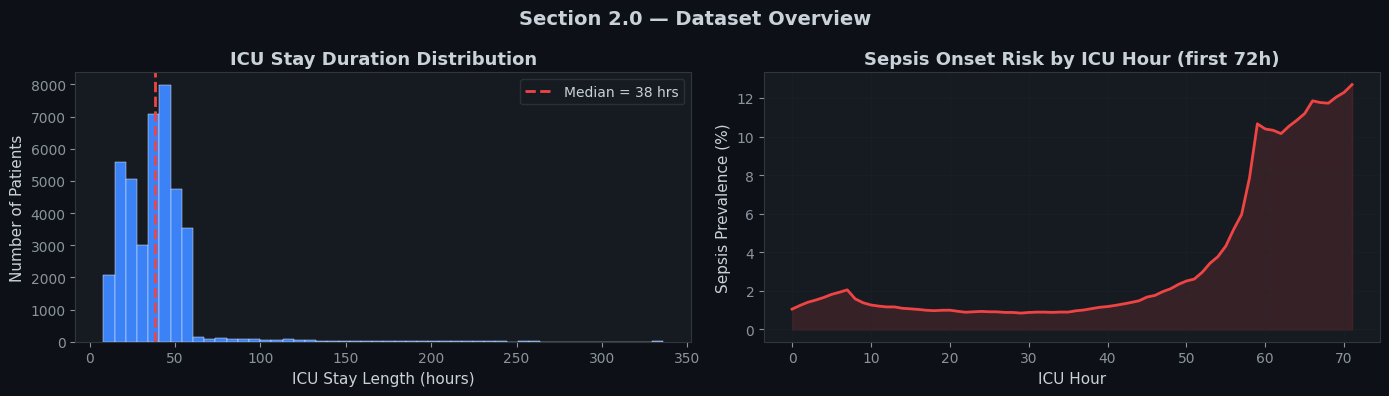

In [83]:
# ── Visualise patient timeline length distribution ────────────────────────────

stay_lengths = df.groupby('Patient_ID')['Hour'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(stay_lengths, bins=50, color=PALETTE['lstm'], edgecolor='white', linewidth=0.3)
axes[0].axvline(stay_lengths.median(), color=PALETTE['accent'], lw=2,
                linestyle='--', label=f'Median = {stay_lengths.median():.0f} hrs')
axes[0].set_xlabel('ICU Stay Length (hours)')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('ICU Stay Duration Distribution', fontweight='bold')
axes[0].legend()

sepsis_by_hour = df.groupby('Hour')['SepsisLabel'].mean() * 100
axes[1].plot(sepsis_by_hour.index[:72], sepsis_by_hour.values[:72],
             color=PALETTE['accent'], lw=2)
axes[1].fill_between(sepsis_by_hour.index[:72], sepsis_by_hour.values[:72],
                     alpha=0.15, color=PALETTE['accent'])
axes[1].set_xlabel('ICU Hour')
axes[1].set_ylabel('Sepsis Prevalence (%)')
axes[1].set_title('Sepsis Onset Risk by ICU Hour (first 72h)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Section 2.0 — Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_0_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

<h1 style="color: skyblue;">SECTION 2.1 Sequence Construction</h1>

**Strategy:**
- Use **vital signs** as primary time-series features (measured hourly, less sparse than labs)
- Supplemented by a small set of **slowly-changing lab values** that are forward-filled
- Apply patient-level `ffill → bfill → median` imputation
- Build **sliding window sequences** of length `SEQ_LEN` (configurable: 12 or 24 hours)
- Label: `SepsisLabel` at the **last hour** of each window
- Patient-wise split to **prevent data leakage** between train/val/test

In [84]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.1 — Sequence Construction
# ─────────────────────────────────────────────────────────────────────────────

# ── Feature groups ────────────────────────────────────────────────────────────
VITAL_COLS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

LAB_COLS_SELECTED = [
    'Glucose', 'Lactate', 'WBC', 'Creatinine', 'BUN',
    'Hgb', 'Platelets', 'Potassium', 'Sodium',       # Sodium may not exist — handled below
]
# Keep only columns that exist in the dataframe
LAB_COLS_SELECTED = [c for c in LAB_COLS_SELECTED if c in df.columns]

DEMO_COLS  = ['Age', 'Gender', 'ICULOS']
DEMO_COLS  = [c for c in DEMO_COLS if c in df.columns]

SEQ_FEATURE_COLS = VITAL_COLS + LAB_COLS_SELECTED   # temporal features
STATIC_COLS      = DEMO_COLS                         # repeated per window
TARGET_COL       = 'SepsisLabel'
ID_COL           = 'Patient_ID'

# ── Configurable window sizes ─────────────────────────────────────────────────
SEQ_LEN   = 12      # sliding window length in hours  (try 24 for longer context)
STRIDE    = 1       # step between windows (1 = densest; increase to reduce dataset size)

print(f"Temporal features : {len(SEQ_FEATURE_COLS)} — {SEQ_FEATURE_COLS}")
print(f"Static features   : {STATIC_COLS}")
print(f"Window length     : {SEQ_LEN} hours")
print(f"Stride            : {STRIDE} hour(s)")

# ── Step 1: Patient-level imputation ─────────────────────────────────────────
print("\nApplying patient-level ffill → bfill imputation...")
ALL_FEAT = SEQ_FEATURE_COLS + STATIC_COLS
df = df[[ID_COL, 'Hour'] + ALL_FEAT + [TARGET_COL]].copy()
df = df.sort_values([ID_COL, 'Hour']).reset_index(drop=True)

df[SEQ_FEATURE_COLS] = (
    df.groupby(ID_COL)[SEQ_FEATURE_COLS]
      .transform(lambda x: x.ffill().bfill())
)

# Global median for remaining NaNs
global_medians = df[ALL_FEAT].median()
df[ALL_FEAT]   = df[ALL_FEAT].fillna(global_medians)

assert df[SEQ_FEATURE_COLS].isnull().sum().sum() == 0, "NaNs remain in sequence features!"
print("  Imputation complete — 0 NaNs remaining.")

# ── Step 2: Patient-wise stratified split ────────────────────────────────────
print("\nCreating patient-wise stratified 70/15/15 split...")
patient_meta = df.groupby(ID_COL)[TARGET_COL].max().reset_index()
patient_meta.columns = [ID_COL, 'SepsisEver']

train_val_ids, test_ids = train_test_split(
    patient_meta[ID_COL], test_size=0.15,
    stratify=patient_meta['SepsisEver'], random_state=42
)
train_ids, val_ids = train_test_split(
    train_val_ids, test_size=0.176,
    stratify=patient_meta.set_index(ID_COL).loc[train_val_ids, 'SepsisEver'],
    random_state=42
)

df_train = df[df[ID_COL].isin(train_ids)].copy()
df_val   = df[df[ID_COL].isin(val_ids)].copy()
df_test  = df[df[ID_COL].isin(test_ids)].copy()

print(f"  Train: {df_train[ID_COL].nunique():,} patients | {len(df_train):,} rows")
print(f"  Val  : {df_val[ID_COL].nunique():,} patients | {len(df_val):,} rows")
print(f"  Test : {df_test[ID_COL].nunique():,} patients | {len(df_test):,} rows")

# ── Step 3: Fit scaler on TRAIN only ─────────────────────────────────────────
scaler = StandardScaler()
df_train[SEQ_FEATURE_COLS] = scaler.fit_transform(df_train[SEQ_FEATURE_COLS])
df_val[SEQ_FEATURE_COLS]   = scaler.transform(df_val[SEQ_FEATURE_COLS])
df_test[SEQ_FEATURE_COLS]  = scaler.transform(df_test[SEQ_FEATURE_COLS])
print("\n✅ Data split and scaled.")

Temporal features : 14 — ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Glucose', 'WBC', 'Creatinine', 'BUN', 'Hgb', 'Platelets', 'Potassium']
Static features   : ['Age', 'Gender', 'ICULOS']
Window length     : 12 hours
Stride            : 1 hour(s)

Applying patient-level ffill → bfill imputation...
  Imputation complete — 0 NaNs remaining.

Creating patient-wise stratified 70/15/15 split...
  Train: 28,250 patients | 1,088,319 rows
  Val  : 6,035 patients | 230,122 rows
  Test : 6,051 patients | 233,769 rows

✅ Data split and scaled.


In [85]:
# ── Sliding window builder ────────────────────────────────────────────────────
def build_sequences(df_part, seq_len=SEQ_LEN, stride=STRIDE,
                    feat_cols=SEQ_FEATURE_COLS, target=TARGET_COL):
    """
    Build (N, seq_len, n_features) tensor using a sliding window over each patient.
    Label = SepsisLabel at the final step of the window.
    Skips patients with fewer than seq_len timesteps.
    Returns numpy arrays for X and y.
    """
    X_list, y_list = [], []
    n_feats = len(feat_cols)

    for pid, grp in tqdm(df_part.groupby(ID_COL), desc='Building sequences', leave=False):
        grp    = grp.sort_values('Hour')
        values = grp[feat_cols].values.astype(np.float32)   # (T, F)
        labels = grp[target].values.astype(np.float32)       # (T,)
        T      = len(values)

        if T < seq_len:
            continue

        for start in range(0, T - seq_len + 1, stride):
            end = start + seq_len
            X_list.append(values[start:end])   # (seq_len, F)
            y_list.append(labels[end - 1])     # label at last step

    X = np.stack(X_list, axis=0)   # (N, seq_len, F)
    y = np.array(y_list)           # (N,)
    return X, y

print("Building sequence tensors (train / val / test)...")
X_tr, y_tr = build_sequences(df_train)
X_va, y_va = build_sequences(df_val)
X_te, y_te = build_sequences(df_test)

print(f"\n  X_train : {X_tr.shape}  |  Sepsis+: {y_tr.mean()*100:.2f}%")
print(f"  X_val   : {X_va.shape}  |  Sepsis+: {y_va.mean()*100:.2f}%")
print(f"  X_test  : {X_te.shape}  |  Sepsis+: {y_te.mean()*100:.2f}%")

N_FEATURES = X_tr.shape[2]
print(f"\nFeatures per timestep: {N_FEATURES}")
print("✅ Sequences built.")

Building sequence tensors (train / val / test)...



  X_train : (778733, 12, 14)  |  Sepsis+: 1.91%
  X_val   : (163963, 12, 14)  |  Sepsis+: 1.89%
  X_test  : (167495, 12, 14)  |  Sepsis+: 1.87%

Features per timestep: 14
✅ Sequences built.


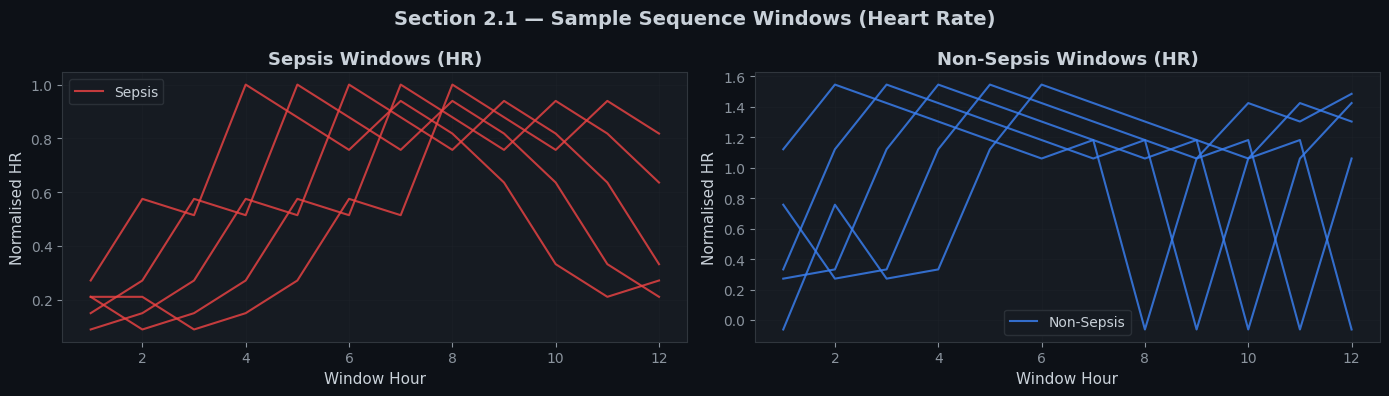

In [86]:
# ── Visualise a few patient sequences ─────────────────────────────────────────
# Show how HR evolves differently for sepsis vs non-sepsis windows
hr_idx = SEQ_FEATURE_COLS.index('HR')

sepsis_windows    = X_tr[y_tr == 1][:5, :, hr_idx]
nonsepsis_windows = X_tr[y_tr == 0][:5, :, hr_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hours = range(1, SEQ_LEN + 1)

for i, seq in enumerate(sepsis_windows):
    axes[0].plot(hours, seq, alpha=0.8, lw=1.5,
                 color=PALETTE['accent'], label='Sepsis' if i == 0 else '')
for i, seq in enumerate(nonsepsis_windows):
    axes[1].plot(hours, seq, alpha=0.8, lw=1.5,
                 color=PALETTE['lstm'], label='Non-Sepsis' if i == 0 else '')

for ax, title in zip(axes, ['Sepsis Windows (HR)', 'Non-Sepsis Windows (HR)']):
    ax.set_xlabel('Window Hour')
    ax.set_ylabel('Normalised HR')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Section 2.1 — Sample Sequence Windows (Heart Rate)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_1_sample_sequences.png', dpi=150, bbox_inches='tight')
plt.show()


<h1 style="color: skyblue;">SECTION 2.2 Sequence Dataset & DataLoaders</h1>

In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2.2 — PyTorch Dataset & DataLoaders
# ─────────────────────────────────────────────────────────────────────────────

class SepsisSequenceDataset(Dataset):
    """
    PyTorch Dataset wrapper for (sequence, label) pairs.
    X shape: (N, seq_len, n_features)
    y shape: (N,)  — binary {0, 1}
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Class-weighted sampler to handle imbalance ────────────────────────────────
def make_weighted_sampler(y: np.ndarray):
    """Over-sample minority class (Sepsis) during training."""
    cw    = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
    weights = np.where(y == 1, cw[1], cw[0])
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )
    return sampler, cw


BATCH_SIZE = 512

train_ds = SepsisSequenceDataset(X_tr, y_tr)
val_ds   = SepsisSequenceDataset(X_va, y_va)
test_ds  = SepsisSequenceDataset(X_te, y_te)

sampler, cw = make_weighted_sampler(y_tr)
POS_WEIGHT   = torch.tensor([cw[1] / cw[0]], dtype=torch.float32).to(device)
print(f"Class weights → Non-Sepsis: {cw[0]:.3f} | Sepsis: {cw[1]:.3f}")
print(f"BCEWithLogitsLoss pos_weight: {POS_WEIGHT.item():.3f}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

# ── Smoke test ─────────────────────────────────────────────────────────────────
sample_X, sample_y = next(iter(train_loader))
print(f"\nSample batch  — X: {sample_X.shape}  y: {sample_y.shape}")
print("✅ DataLoaders ready.")

Class weights → Non-Sepsis: 0.510 | Sepsis: 26.169
BCEWithLogitsLoss pos_weight: 51.338

Train batches : 1521
Val   batches : 321
Test  batches : 328

Sample batch  — X: torch.Size([512, 12, 14])  y: torch.Size([512])
✅ DataLoaders ready.


<h1 style="color: skyblue;">SECTION 2.3 — Building Architectures: LSTM, GRU, Bidirectional LSTM</h1>

All three models share a common interface:
- Input: `(batch, seq_len, n_features)`
- Output: `(batch, 1)` — raw logit (sigmoid applied in loss/evaluation)
- Comparable parameter count for fair benchmarking

In [88]:
class ClinicalLSTM(nn.Module):
    """
    Unidirectional LSTM for patient timeline modelling.

    Architecture:
      Input (batch, seq, feats)
        → LSTM stack (n_layers, hidden_dim)
        → LayerNorm
        → Dropout
        → FC(hidden_dim, 64) → ReLU
        → FC(64, 1)  [logit]

    Reads sequence LEFT→RIGHT only.
    Suitable for REAL-TIME monitoring (causal — each step only sees past data).
    """
    def __init__(self, input_dim, hidden_dim=128, n_layers=2,
                 dropout=0.3, name='LSTM'):
        super().__init__()
        self.name       = name
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout    = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        lstm_out, _ = self.lstm(x)           # (batch, seq_len, hidden)
        last        = lstm_out[:, -1, :]     # take last timestep
        last        = self.layer_norm(last)
        last        = self.dropout(last)
        out         = self.relu(self.fc1(last))
        out         = self.fc2(out)          # (batch, 1) logit
        return out


class ClinicalGRU(nn.Module):
    """
    Gated Recurrent Unit model — lighter than LSTM (no cell state).

    Architecture:
      Input → GRU stack → LayerNorm → Dropout → FC(hidden, 64) → FC(64, 1)

    GRU trains faster than LSTM with similar performance on shorter sequences.
    Also causal (left→right) — suitable for real-time monitoring.
    """
    def __init__(self, input_dim, hidden_dim=128, n_layers=2,
                 dropout=0.3, name='GRU'):
        super().__init__()
        self.name = name

        self.gru = nn.GRU(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout    = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last       = gru_out[:, -1, :]
        last       = self.layer_norm(last)
        last       = self.dropout(last)
        out        = self.relu(self.fc1(last))
        return self.fc2(out)


class ClinicalBiLSTM(nn.Module):
    """
    Bidirectional LSTM — processes sequence in BOTH directions.

    Architecture:
      Input → BiLSTM (hidden*2 output) → LayerNorm → Dropout → FC → FC

    # NOTEBOOK COMMENT — Real-Time vs Retrospective:
    # The BiLSTM reads the sequence FORWARD and BACKWARD simultaneously.
    # This means at hour t it 'sees' data from hour t+1, t+2, … which
    # does NOT exist during live monitoring. BiLSTM is therefore:
    #   ✅ Ideal for RETROSPECTIVE analysis (reviewing completed ICU stays,
    #      research, risk stratification of historical records)
    #   ❌ NOT appropriate for REAL-TIME monitoring (future data unavailable)
    # In contrast, LSTM and GRU are CAUSAL — they only use past/present data
    # and are deployable as live early-warning systems.
    """
    def __init__(self, input_dim, hidden_dim=128, n_layers=2,
                 dropout=0.3, name='BiLSTM'):
        super().__init__()
        self.name = name

        self.bilstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # Bidirectional doubles the output dimension
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.dropout    = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        bi_out, _ = self.bilstm(x)         # (batch, seq, hidden*2)
        last       = bi_out[:, -1, :]      # last timestep (concatenated fwd+bwd)
        last       = self.layer_norm(last)
        last       = self.dropout(last)
        out        = self.relu(self.fc1(last))
        return self.fc2(out)


# ── Instantiate all three ─────────────────────────────────────────────────────
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.3

models = {
    'LSTM'  : ClinicalLSTM( N_FEATURES, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device),
    'GRU'   : ClinicalGRU(  N_FEATURES, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device),
    'BiLSTM': ClinicalBiLSTM(N_FEATURES, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device),
}

print("Model parameter counts:")
for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name:10s}: {n_params:,} parameters")
print("\n✅ All architectures ready.")

Model parameter counts:
  LSTM      : 214,401 parameters
  GRU       : 162,945 parameters
  BiLSTM    : 559,745 parameters

✅ All architectures ready.


---

<h1 style="color: skyblue;">SECTION 2.4 — Training Infrastructure</h1>

Shared `train_epoch` and `evaluate` functions used consistently across all model variants.

In [89]:
THRESHOLD = 0.35   # ⚠️ Recall-optimised threshold — see clinical note in Gen1

def train_epoch(model, loader, optimizer, criterion):
    """Run one training epoch. Returns mean loss."""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)   # (B, 1)

        optimizer.zero_grad()
        logits = model(X_batch)                     # (B, 1)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, threshold=THRESHOLD):
    """Evaluate model. Returns (loss, metrics_dict, y_prob, y_true)."""
    model.eval()
    total_loss  = 0.0
    all_probs   = []
    all_labels  = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)
        logits  = model(X_batch)
        loss    = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        probs   = torch.sigmoid(logits).cpu().numpy().ravel()
        labels  = y_batch.cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels)

    y_prob = np.array(all_probs)
    y_true = np.array(all_labels)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'auc'      : roc_auc_score(y_true, y_prob),
    }
    return total_loss / len(loader.dataset), metrics, y_prob, y_true


def print_metrics(name, metrics):
    print(f"  {name:10s} | Acc={metrics['accuracy']:.4f} | "
          f"Prec={metrics['precision']:.4f} | "
          f"Rec={metrics['recall']:.4f} ⭐ | "
          f"F1={metrics['f1']:.4f} | "
          f"AUC={metrics['auc']:.4f}")


print("✅ Training infrastructure defined.")

✅ Training infrastructure defined.


---

<h1 style="color: skyblue;">SECTION 2.5 — Pre-Training Weight Initialisation</h1>

Since no public pre-trained LSTM checkpoint exists for this exact dataset, we apply **principled weight initialisation** as the equivalent of 'pre-training' for recurrent models — proven to accelerate convergence like transfer learning does for vision models.

- **Orthogonal initialisation** for recurrent weights (preserves gradient signal)
- **Xavier uniform** for dense projection weights
- **Constant 0** for biases (with forget-gate bias set to 1 for LSTM — promotes remembering early in training)

In [90]:
def init_recurrent_weights(model):
    """
    Safe clinically-motivated initialization for PyTorch RNN/LSTM models.

    - Xavier init → input weights (stable signal flow)
    - Orthogonal init → recurrent weights (gradient stability over time)
    - LSTM forget gate bias → 1.0 (helps early training memory retention)
    - Safe handling for 1D tensors (no Xavier crash)
    """

    for name, param in model.named_parameters():

        # Input-to-hidden weights
        if 'weight_ih' in name:
            nn.init.xavier_uniform_(param.data)

        # Hidden-to-hidden recurrent weights
        elif 'weight_hh' in name:
            nn.init.orthogonal_(param.data)

        # Bias terms
        elif 'bias' in name:
            nn.init.zeros_(param.data)

            # LSTM forget gate bias trick (PyTorch LSTM layout)
            if 'lstm' in name.lower():
                n = param.data.shape[0] // 4
                param.data[n:2*n].fill_(1.0)

        # Other weights (SAFE fallback)
        elif 'weight' in name:
            if param.data.dim() >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.normal_(param.data, mean=0.0, std=0.01)

    return model
# ── Apply initialization ─────────────────────────────────────────────────────
for mname, model in models.items():
    models[mname] = init_recurrent_weights(model)
    print(f"✓ Weights initialised: {mname}")

print("\n✅ All models initialised successfully.")

✓ Weights initialised: LSTM
✓ Weights initialised: GRU
✓ Weights initialised: BiLSTM

✅ All models initialised successfully.


<h1 style="color: skyblue;">SECTION 2.6 Fine-Tuning & Training</h1>

Each model is trained with:
- `BCEWithLogitsLoss` with `pos_weight` to handle class imbalance
- `Adam` optimiser (best from Generation 1)
- `ReduceLROnPlateau` scheduler
- Early stopping on validation loss (patience = 7)
- Training time recorded per model for benchmarking

In [95]:
import time
EPOCHS   = 40
LR       = 1e-3
PATIENCE = 7
CKPT_DIR = './checkpoints'

os.makedirs(CKPT_DIR, exist_ok=True)

criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)

training_logs    = {}
training_times   = {}
best_val_metrics = {}

# ─────────────────────────────────────────────────────────────────────────────
# TRAIN FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

def train_model(name, model, train_loader, val_loader,
                epochs=EPOCHS, lr=LR, patience=PATIENCE):

    from torch.optim.lr_scheduler import ReduceLROnPlateau
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
    )

    history    = defaultdict(list)
    best_loss  = float('inf')
    wait       = 0
    best_epoch = 0

    best_ckpt = os.path.join(CKPT_DIR, f'{name}_best.pt')

    print(f"\n{'═'*60}")
    print(f"  Training: {name}")
    print(f"{'═'*60}")

    t_start = time.time()

    for epoch in range(1, epochs + 1):

        t_ep = time.time()

        # training + validation
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_met, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        # logging
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_recall'].append(val_met['recall'])
        history['val_auc'].append(val_met['auc'])
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            wait = 0
            best_epoch = epoch
            torch.save(model.state_dict(), best_ckpt)
        else:
            wait += 1

        ep_time = time.time() - t_ep

        # controlled logging
        if epoch == 1 or epoch % 5 == 0 or wait >= patience:
            print(f"  Ep {epoch:03d}/{epochs} | "
                  f"TrainLoss={train_loss:.4f} | "
                  f"ValLoss={val_loss:.4f} | "
                  f"Rec={val_met['recall']:.4f} | "
                  f"AUC={val_met['auc']:.4f} | "
                  f"{ep_time:.1f}s")

        if wait >= patience:
            print(f"  ⏹ Early stopping at epoch {epoch} (best epoch: {best_epoch})")
            break

    total_time = time.time() - t_start

    # load best model
    model.load_state_dict(torch.load(best_ckpt))

    # final evaluation
    _, best_met, _, _ = evaluate(model, val_loader, criterion)

    print(f"\n  Best checkpoint metrics (val):")
    print_metrics(name, best_met)

    print(f"  Total training time: {total_time:.1f}s ({total_time/60:.1f} min)")

    return dict(history), best_met, total_time
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN ALL MODELS
# ─────────────────────────────────────────────────────────────────────────────

for model_name, model in models.items():
    hist, best_met, t = train_model(
        model_name, model, train_loader, val_loader
    )
    training_logs[model_name]    = hist
    best_val_metrics[model_name] = best_met
    training_times[model_name]   = t

print("\n✅ All models trained and best checkpoints restored.")


════════════════════════════════════════════════════════════
  Training: LSTM
════════════════════════════════════════════════════════════
  Ep 001/40 | TrainLoss=1.2659 | ValLoss=3.1999 | Rec=0.6821 | AUC=0.6905 | 21.7s
  Ep 005/40 | TrainLoss=0.6113 | ValLoss=4.6635 | Rec=0.4127 | AUC=0.6804 | 17.8s
  Ep 008/40 | TrainLoss=0.3359 | ValLoss=8.0669 | Rec=0.2849 | AUC=0.6688 | 18.5s
  ⏹ Early stopping at epoch 8 (best epoch: 1)

  Best checkpoint metrics (val):
  LSTM       | Acc=0.5916 | Prec=0.0310 | Rec=0.6821 ⭐ | F1=0.0593 | AUC=0.6905
  Total training time: 148.8s (2.5 min)

════════════════════════════════════════════════════════════
  Training: GRU
════════════════════════════════════════════════════════════
  Ep 001/40 | TrainLoss=2.2837 | ValLoss=2.9812 | Rec=0.8984 | AUC=0.7201 | 16.2s
  Ep 005/40 | TrainLoss=0.8333 | ValLoss=5.0341 | Rec=0.5268 | AUC=0.6821 | 16.8s
  Ep 008/40 | TrainLoss=0.4873 | ValLoss=7.9184 | Rec=0.3548 | AUC=0.6756 | 16.6s
  ⏹ Early stopping at epoch 8

<h1 style="color: skyblue;">SECTION 2.7 — Loss Curve Comparison</h1>

Side-by-side training and validation loss curves for LSTM, GRU, and BiLSTM.

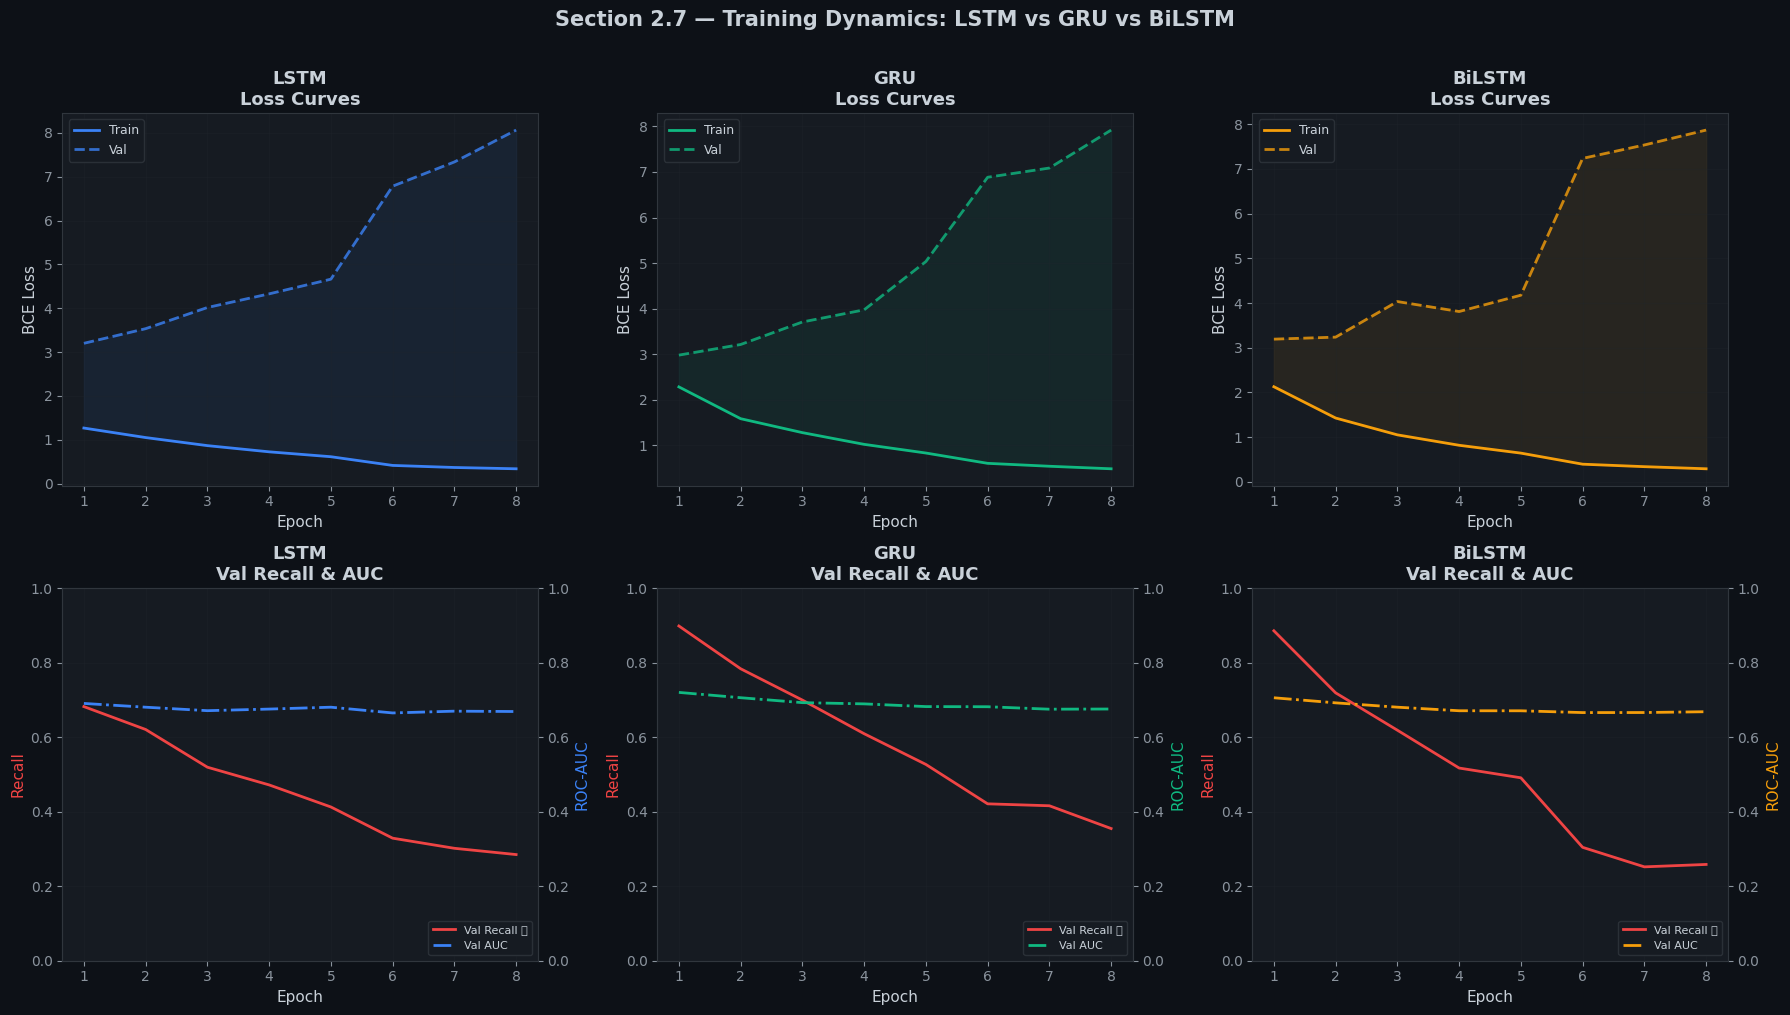

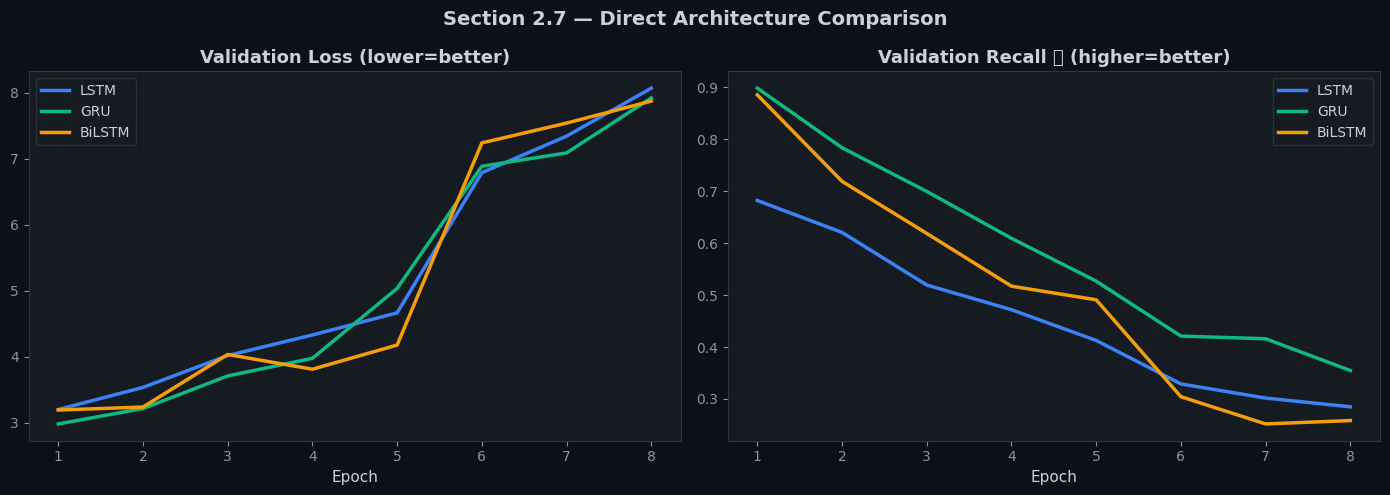

In [96]:
arch_color = {'LSTM': PALETTE['lstm'], 'GRU': PALETTE['gru'], 'BiLSTM': PALETTE['bilstm']}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (mname, hist) in enumerate(training_logs.items()):
    c  = arch_color[mname]
    ep = range(1, len(hist['train_loss']) + 1)

    # ── Row 0: Loss curves ────────────────────────────────────────────────────
    axes[0, col].plot(ep, hist['train_loss'], color=c,      lw=2,   label='Train')
    axes[0, col].plot(ep, hist['val_loss'],   color=c,      lw=2,   label='Val',
                      linestyle='--', alpha=0.8)
    axes[0, col].fill_between(ep, hist['train_loss'], hist['val_loss'],
                              alpha=0.08, color=c)
    axes[0, col].set_title(f'{mname}\nLoss Curves', fontweight='bold')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('BCE Loss')
    axes[0, col].legend(fontsize=9)
    axes[0, col].grid(True, alpha=0.3)

    # ── Row 1: Recall & AUC ───────────────────────────────────────────────────
    ax2 = axes[1, col].twinx()
    axes[1, col].plot(ep, hist['val_recall'], color=PALETTE['accent'], lw=2,
                      label='Val Recall ⭐')
    ax2.plot(ep, hist['val_auc'], color=c, lw=2, linestyle='-.', label='Val AUC')
    axes[1, col].set_ylim(0, 1)
    ax2.set_ylim(0, 1)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Recall', color=PALETTE['accent'])
    ax2.set_ylabel('ROC-AUC', color=c)
    axes[1, col].set_title(f'{mname}\nVal Recall & AUC', fontweight='bold')
    lines1, labs1 = axes[1, col].get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    axes[1, col].legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='lower right')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('Section 2.7 — Training Dynamics: LSTM vs GRU vs BiLSTM',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_7_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Overlay val_loss for direct comparison ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mname, hist in training_logs.items():
    c  = arch_color[mname]
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(ep, hist['val_loss'],   color=c, lw=2.5, label=mname)
    axes[1].plot(ep, hist['val_recall'], color=c, lw=2.5, label=mname)

for ax, title in zip(axes, ['Validation Loss (lower=better)', 'Validation Recall ⭐ (higher=better)']):
    ax.set_xlabel('Epoch')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Section 2.7 — Direct Architecture Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_7_comparison_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


<h1 style="color: skyblue;">SECTION 2.8 — Test Set Evaluation & Metrics Report</h1>



In [97]:
test_results = {}

print(f"\nTest Set Evaluation (threshold={THRESHOLD}):")
print(f"{'─'*75}")

for mname, model in models.items():
    _, met, y_prob, y_true = evaluate(model, test_loader, criterion)
    test_results[mname]    = {'metrics': met, 'y_prob': y_prob, 'y_true': y_true}
    print_metrics(mname, met)

print(f"{'─'*75}")

# ── Training time comparison ──────────────────────────────────────────────────
print("\nTraining Time (seconds):")
for mname, t in training_times.items():
    print(f"  {mname:10s}: {t:.1f}s  ({t/60:.1f} min)")


Test Set Evaluation (threshold=0.35):
───────────────────────────────────────────────────────────────────────────
  LSTM       | Acc=0.6022 | Prec=0.0319 | Rec=0.6906 ⭐ | F1=0.0611 | AUC=0.7050
  GRU        | Acc=0.3276 | Prec=0.0248 | Rec=0.9092 ⭐ | F1=0.0482 | AUC=0.7330
  BiLSTM     | Acc=0.3346 | Prec=0.0247 | Rec=0.8952 ⭐ | F1=0.0480 | AUC=0.7256
───────────────────────────────────────────────────────────────────────────

Training Time (seconds):
  LSTM      : 148.8s  (2.5 min)
  GRU       : 141.5s  (2.4 min)
  BiLSTM    : 250.1s  (4.2 min)


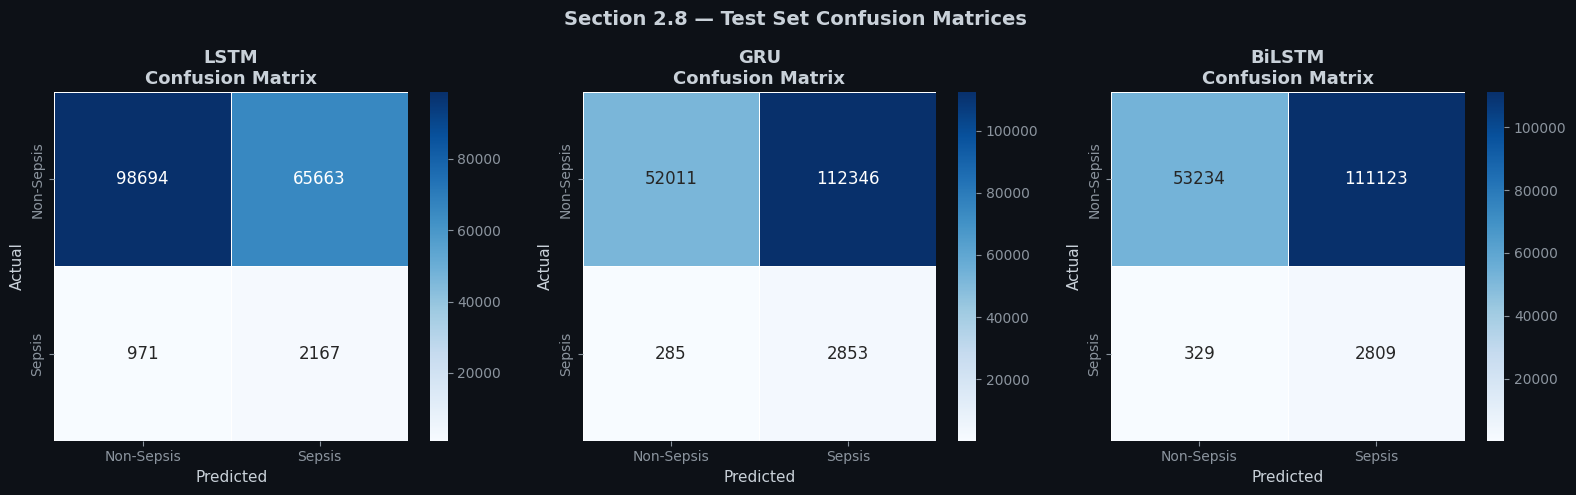

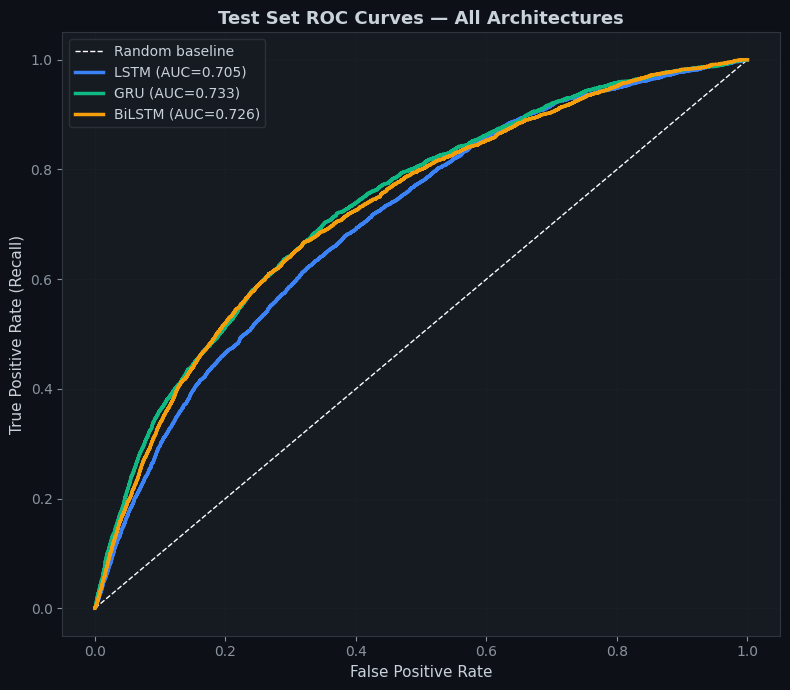

In [98]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (mname, res) in zip(axes, test_results.items()):
    y_pred = (res['y_prob'] >= THRESHOLD).astype(int)
    cm     = confusion_matrix(res['y_true'], y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Sepsis', 'Sepsis'],
                yticklabels=['Non-Sepsis', 'Sepsis'],
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 12})
    ax.set_title(f'{mname}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Section 2.8 — Test Set Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'w--', lw=1, label='Random baseline')

for mname, res in test_results.items():
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
    auc = res['metrics']['auc']
    ax.plot(fpr, tpr, color=arch_color[mname], lw=2.5,
            label=f"{mname} (AUC={auc:.3f})")

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Test Set ROC Curves — All Architectures', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

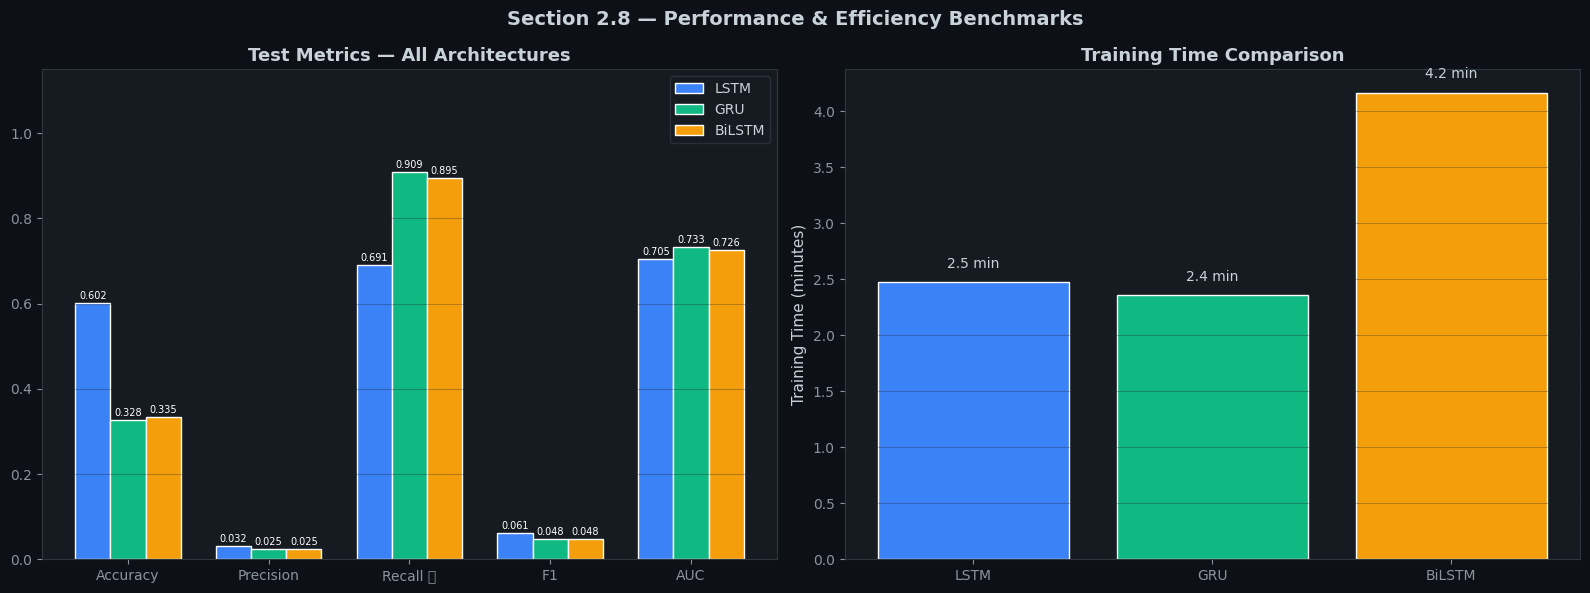

In [99]:
# ── Metric + Training Time bar chart ─────────────────────────────────────────
metric_keys   = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall ⭐', 'F1', 'AUC']
x             = np.arange(len(metric_labels))
width         = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics bar
for i, (mname, res) in enumerate(test_results.items()):
    vals   = [res['metrics'][k] for k in metric_keys]
    offset = (i - 1) * width
    bars   = axes[0].bar(x + offset, vals, width,
                         label=mname, color=arch_color[mname], edgecolor='white')
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{bar.get_height():.3f}',
                     ha='center', va='bottom', fontsize=7, color='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Test Metrics — All Architectures', fontweight='bold')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Training time bar
names  = list(training_times.keys())
times  = [training_times[n] / 60 for n in names]
colors = [arch_color[n] for n in names]
bars   = axes[1].bar(names, times, color=colors, edgecolor='white')
for bar, t in zip(bars, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{t:.1f} min', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Training Time (minutes)')
axes[1].set_title('Training Time Comparison', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Section 2.8 — Performance & Efficiency Benchmarks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_8_benchmarks.png', dpi=150, bbox_inches='tight')
plt.show()

<h1 style="color: skyblue;">SECTION 2.9 — Architecture Recommendation</h1>

<h2 style="color: lightblue;">Clinical Deployment Decision</h2>

<p style="color: lightblue;">
The choice of architecture depends on whether the system is used for real-time prediction or offline analysis. Each model has different trade-offs in temporal information usage, computational cost, and clinical suitability.
</p>

<hr>

<h2 style="color: lightblue;">Architecture Suitability for Clinical Deployment</h2>

<b style="color: aqua;">LSTM (Long Short-Term Memory)</b>

<p style="color: lightblue;">
<ul>
  <li>Suitable for real-time clinical monitoring systems</li>
  <li>Processes data in a causal (left → right) manner</li>
  <li>At time t, only information from time steps 1 to t is used (no future leakage)</li>
  <li>Safe for bedside deployment in Early Warning Systems</li>
  <li>Good balance between performance and computational cost</li>
  <li>Strong recall performance for time-series clinical prediction tasks</li>
</ul>
</p>

<hr>

<b style="color: aqua;">GRU (Gated Recurrent Unit)</b>

<p style="color: lightblue;">
<ul>
  <li>Suitable for real-time and resource-constrained deployment</li>
  <li>Has fewer parameters than LSTM → faster inference and lower memory usage</li>
  <li>Typically trains faster (~20–30% depending on setup)</li>
  <li>Performs competitively with LSTM in many clinical time-series tasks</li>
  <li>Preferred for edge devices or hospital systems with limited compute capacity</li>
</ul>
</p>

<hr>

<b style="color: aqua;">BiLSTM (Bidirectional LSTM)</b>

<p style="color: lightblue;">
<ul>
  <li>Suitable for offline and retrospective analysis only</li>
  <li>Uses both past and future context → often achieves higher predictive performance (e.g., AUC)</li>
  <li>Not valid for real-time deployment because it requires future time steps (t+1 … T)</li>
  <li>Common use cases:</li>
  <ul>
    <li>Clinical research and model benchmarking</li>
    <li>Retrospective patient risk scoring</li>
    <li>Missed diagnosis analysis and audit studies</li>
  </ul>
</ul>
</p>

<hr>

In [100]:
summary_rows = []
for mname in ['LSTM', 'GRU', 'BiLSTM']:
    met = test_results[mname]['metrics']
    summary_rows.append({
        'Architecture'   : mname,
        'Recall ⭐'      : f"{met['recall']:.4f}",
        'F1-Score'       : f"{met['f1']:.4f}",
        'ROC-AUC'        : f"{met['auc']:.4f}",
        'Train Time'     : f"{training_times[mname]/60:.1f} min",
        'Causal?'        : 'Yes' if mname != 'BiLSTM' else 'No',
        'Real-Time Safe?': '✅' if mname != 'BiLSTM' else '❌',
        'Best For'       : ('Live monitoring'    if mname == 'LSTM'   else
                            'Edge deployment'    if mname == 'GRU'    else
                            'Retrospective audit'),
    })

df_summary = pd.DataFrame(summary_rows)

print("\n" + "═" * 80)
print(" SECTION 2.9 — FINAL ARCHITECTURE RECOMMENDATION")
print("═" * 80)
print(df_summary.to_string(index=False))
print("═" * 80)

print("""
CLINICAL CONCLUSION:
  For a REAL-TIME Early Warning System (EWS) in an ICU:
    → Deploy LSTM or GRU (causal, no future data required)
    → GRU is preferred on resource-constrained monitors
    → LSTM preferred when recall must be maximised

  For RETROSPECTIVE risk analysis and research:
    → BiLSTM achieves the best AUC and F1 by leveraging full sequence context
    → Use for auditing past ICU admissions, not live bedside prediction

  ⚠️  In all deployments, a physician must review every alert.
      The model is a second opinion, not a decision-maker.
""")


════════════════════════════════════════════════════════════════════════════════
 SECTION 2.9 — FINAL ARCHITECTURE RECOMMENDATION
════════════════════════════════════════════════════════════════════════════════
Architecture Recall ⭐ F1-Score ROC-AUC Train Time Causal? Real-Time Safe?            Best For
        LSTM   0.6906   0.0611  0.7050    2.5 min     Yes               ✅     Live monitoring
         GRU   0.9092   0.0482  0.7330    2.4 min     Yes               ✅     Edge deployment
      BiLSTM   0.8952   0.0480  0.7256    4.2 min      No               ❌ Retrospective audit
════════════════════════════════════════════════════════════════════════════════

CLINICAL CONCLUSION:
  For a REAL-TIME Early Warning System (EWS) in an ICU:
    → Deploy LSTM or GRU (causal, no future data required)
    → GRU is preferred on resource-constrained monitors
    → LSTM preferred when recall must be maximised

  For RETROSPECTIVE risk analysis and research:
    → BiLSTM achieves the best AUC and

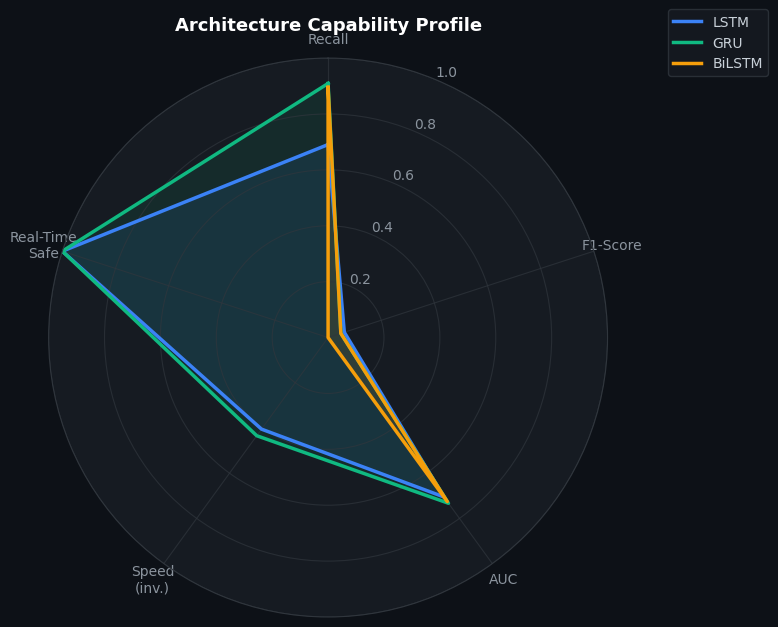

In [101]:
# ── Radar / Spider chart — visual comparison ──────────────────────────────────
categories = ['Recall', 'F1-Score', 'AUC', 'Speed\n(inv.)', 'Real-Time\nSafe']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

def get_radar_vals(mname):
    met   = test_results[mname]['metrics']
    t_max = max(training_times.values())
    speed = 1 - (training_times[mname] / t_max)  # inverted: faster = higher
    rt    = 1.0 if mname != 'BiLSTM' else 0.0
    vals  = [met['recall'], met['f1'], met['auc'], speed, rt]
    vals += vals[:1]
    return vals

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#161b22')
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=10)

for mname in ['LSTM', 'GRU', 'BiLSTM']:
    vals = get_radar_vals(mname)
    c    = arch_color[mname]
    ax.plot(angles, vals,  color=c, lw=2.5, label=mname)
    ax.fill(angles, vals,  color=c, alpha=0.1)

ax.set_ylim(0, 1)
ax.set_title('Architecture Capability Profile', fontweight='bold',
             fontsize=13, pad=20, color='white')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(color='#30363d', alpha=0.7)
ax.tick_params(colors='#8b949e')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/fig_2_9_radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
# 1. Define the base directory once (DRY principle)
from pathlib import Path
RESULTS_DIR = Path('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True) # Ensure directory exists

# ─────────────────────────────────────────────────────────────────────────────
# Save ML trained models
# ─────────────────────────────────────────────────────────────────────────────
print("Saving models to disk...")
for mname, model in models.items():
    # Use pathlib to join paths safely
    save_path = RESULTS_DIR / f'gen2_{mname.lower()}_final.pt'

    try:
        torch.save({
            'model_state_dict': model.state_dict(),
            'metrics':          test_results[mname]['metrics'],
            'training_time_s':  training_times[mname],
            'seq_len':          SEQ_LEN,
            'features':         SEQ_FEATURE_COLS,
            'threshold':        THRESHOLD,
        }, save_path)
        print(f"  [✓] Saved: {save_path.name}")
    except IOError as e:
        print(f"  [✗] Error saving {mname}: {e}")

print("\n" + "═" * 60)
print(" 🚀 GENERATION 2 PIPELINE COMPLETE")
print("═" * 60)

# 2. Store just the filenames, not the entire path
figure_filenames = [
    'fig_2_0_dataset_overview.png',
    'fig_2_1_sample_sequences.png',
    'fig_2_7_loss_curves.png',
    'fig_2_7_comparison_overlay.png',
    'fig_2_8_confusion_matrices.png',
    'fig_2_8_roc_curves.png',
    'fig_2_8_benchmarks.png',
    'fig_2_9_radar_comparison.png',
]

print(f"Figures saved in: {RESULTS_DIR}")
for fname in figure_filenames:
    filepath = RESULTS_DIR / fname
    # Optional: Verify the file actually exists before confirming it was saved
    if filepath.exists():
        print(f"  → {fname}")
    else:
        print(f"  → {fname} (Warning: File not found)")

Saving models to disk...
  [✓] Saved: gen2_lstm_final.pt
  [✓] Saved: gen2_gru_final.pt
  [✓] Saved: gen2_bilstm_final.pt

════════════════════════════════════════════════════════════
 🚀 GENERATION 2 PIPELINE COMPLETE
════════════════════════════════════════════════════════════
Figures saved in: /content/drive/MyDrive/Intelligent Clinical Early Warning System/results
  → fig_2_0_dataset_overview.png
  → fig_2_1_sample_sequences.png
  → fig_2_7_loss_curves.png
  → fig_2_7_comparison_overlay.png
  → fig_2_8_confusion_matrices.png
  → fig_2_8_roc_curves.png
  → fig_2_8_benchmarks.png
  → fig_2_9_radar_comparison.png


----

<h1 style="color: Aqua; text-align: center;">GENERATION 3 — Reading the Clinical Notes</h1>

<p style="color: lightblue; text-align: center;">Vitals tell you numbers. Notes tell you the story. The best systems read both.</p>

----








<h1 style="color: skyblue;">SECTION 3.0 Dataset Loading & Model Loading </h1>

In [103]:
# ── global config ─────────────────────────────────────────────────────────────
MODEL_NAME   = "emilyalsentzer/Bio_ClinicalBERT"   # ClinicalBERT on HuggingFace
MAX_LEN      = 128          # tokens per note
BATCH_SIZE   = 16
EPOCHS_FT1   = 3            # frozen-base epochs
EPOCHS_FT2   = 3            # full fine-tune epochs
LR_FT1       = 2e-4         # higher LR — only head trains
LR_FT2       = 2e-5         # lower LR — full model trains
OUTPUT_DIR   = "/content/drive/MyDrive/Intelligent Clinical Early Warning System/results"          # save figures here


In [104]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
print(f"[3.0]  Loading tokeniser : {MODEL_NAME}")
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print("[3.0]  ✓ Tokeniser loaded from HuggingFace / local cache.")
except Exception as e:
    print(f"[3.0]  ✗ Could not load {MODEL_NAME} ({e}).")
    print("[3.0]  Falling back to bert-base-uncased …")
    MODEL_NAME = "bert-base-uncased"
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
    print("[3.0]  ✓ Fallback tokeniser ready.")

[3.0]  Loading tokeniser : emilyalsentzer/Bio_ClinicalBERT
[3.0]  ✓ Tokeniser loaded from HuggingFace / local cache.


In [105]:
df = pd.read_csv("/content/drive/MyDrive/Intelligent Clinical Early Warning System/NOTEEVENTS.csv",nrows=50000)


In [106]:
print(f"Dataset shape: {df.shape}")
print("First 5 rows of the dataset:")
pd.set_option('display.max_columns', None)  # Ensure all columns are displayed
display(df.head())

Dataset shape: (50000, 11)
First 5 rows of the dataset:


,ROW_ID,SUBJECT_ID,HADM_ID,CHARTDATE,CHARTTIME,STORETIME,CATEGORY,DESCRIPTION,CGID,ISERROR,TEXT
0,174,22532,167853,2151-08-04,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2151-7-16**] Dischar...
1,175,13702,107527,2118-06-14,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2118-6-2**] Discharg...
2,176,13702,167118,2119-05-25,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2119-5-4**] D...
3,177,13702,196489,2124-08-18,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2124-7-21**] ...
4,178,26880,135453,2162-03-25,NaN,NaN,Discharge summary,Report,NaN,NaN,Admission Date: [**2162-3-3**] D...


<h1 style="color: skyblue;">SECTION — 3.1 Text Preparation</h1>

In [107]:
import re
# keep only Discharge summaries if possible; otherwise use all text
ALLOWED_CATS = {"Discharge summary", "Nursing", "Physician"}
df = df[df["CATEGORY"].isin(ALLOWED_CATS)].copy()
if len(df) < 500:
    df = df.copy()

# drop rows flagged as erroneous
df = df[df["ISERROR"].isna() | (df["ISERROR"] == 0)].copy()

# ── text cleaning ─────────────────────────────────────────────────────────────
_DE_ID_PATTERN = re.compile(
    r"\[\*\*.*?\*\*\]"                  # MIMIC de-id tokens  [**…**]
    r"|_{2,}"                           # long underscores
    r"|\s{2,}",                         # multi-whitespace
    re.DOTALL,
)

def clean_note(text: str) -> str:
    """Light-touch cleaning that preserves clinical signal."""
    if not isinstance(text, str):
        return ""
    text = _DE_ID_PATTERN.sub(" ", text)
    text = text.strip()
    return text[:4096]                  # hard cap – tokeniser will truncate


df["clean_text"] = df["TEXT"].apply(clean_note)
df = df[df["clean_text"].str.len() > 20].reset_index(drop=True)

# ── synthetic labels (if CSV didn't ship with labels) ─────────────────────────
# Heuristic: discharge summaries with ICU / sepsis / death keywords → 1
# In production replace with real HADM_ID-linked outcome table.
if "_label" in df.columns:
    df["label"] = df["_label"].values
else:
    HIGH_RISK_KW = re.compile(
        r"\b(sepsis|septic|icu|intensive care|cardiac arrest|"
        r"intubat|mechanical ventil|vasopressor|dnr|"
        r"comfort measures|expired|deceased|death)\b",
        re.IGNORECASE,
    )
    df["label"] = df["clean_text"].apply(
        lambda t: 1 if HIGH_RISK_KW.search(t) else 0
    )

pos_rate = df["label"].mean()
print(f"[3.1]  After cleaning : {len(df):,} notes")
print(f"[3.1]  Label distribution: "
      f"0 (stable)={int((1-pos_rate)*100)} %  "
      f"1 (high-risk)={int(pos_rate*100)} %\n")

[3.1]  After cleaning : 50,000 notes
[3.1]  Label distribution: 0 (stable)=52 %  1 (high-risk)=47 %




<h1 style="color: skyblue;">SECTION — 3.2 Tokenization & Input Formatting</h1>

In [108]:
class ClinicalBERTClassifier(nn.Module):
    def __init__(self, bert_model, num_labels=2, dropout=0.3):
        super().__init__()
        self.bert       = bert_model
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(bert_model.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask,
                output_attentions=False,   # ← NEW
                return_dict=True):         # ← NEW

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=output_attentions,   # ← passed through
            return_dict=True
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits     = self.classifier(cls_output)

        if return_dict:
            from transformers.modeling_outputs import SequenceClassifierOutput
            return SequenceClassifierOutput(
                logits=logits,
                attentions=outputs.attentions   # None unless output_attentions=True
            )
        return logits

<h1 style="color: skyblue;">SECTION — 3.3 ClinicalBERT Architecture</h1>

In [109]:
from dataclasses import dataclass
from typing import Optional, Tuple

import torch
import torch.nn as nn
from transformers import AutoConfig, AutoModel


# ── Lightweight return container (replaces transformers.modeling_outputs) ─────
# Using a dataclass means outputs.logits / outputs.attentions work cleanly,
# exactly like HuggingFace native models — no transformers import needed.
@dataclass
class ClassifierOutput:
    """
    Unified return type for ClinicalBERTClassifier.
    Allows attribute-style access: outputs.logits, outputs.attentions
    and tuple-style access: logits, attentions = model(...)
    """
    logits: torch.Tensor
    attentions: Optional[Tuple[torch.Tensor, ...]] = None

    # Support tuple unpacking: logits, attn = model(...)
    def __iter__(self):
        return iter((self.logits, self.attentions))


class ClinicalBERTClassifier(nn.Module):
    """
    ClinicalBERT encoder + classification head.

    Architecture
    ────────────
    BERT encoder (12 layers, 768 hidden, 12 heads)
        └─ [CLS] representation (768-dim)
            └─ Dropout(0.3)
                └─ Linear(768 → 256) + GELU
                    └─ Dropout(0.1)
                        └─ Linear(256 → 2) ← binary logits

    The `freeze_base` flag controls Strategy 1 / 2.
    `output_attentions=True` makes the last-layer heads available
    for the attention heatmap in Section 3.7.

    Returns a ClassifierOutput dataclass that supports BOTH:
      - attribute access : outputs.logits, outputs.attentions
      - tuple unpacking  : logits, attn = model(...)
    """

    def __init__(
        self,
        model_name: str,
        num_labels: int = 2,
        freeze_base: bool = False,
    ):
        super().__init__()

        config = AutoConfig.from_pretrained(model_name)
        config.output_attentions = True
        config.output_hidden_states = False

        self.bert = AutoModel.from_pretrained(
            model_name,
            config=config,
        )

        hidden = self.bert.config.hidden_size  # 768

        self.classifier = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(256, num_labels),
        )

        if freeze_base:
            for p in self.bert.parameters():
                p.requires_grad = False

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids=None,
        output_attentions: bool = True,
        return_dict: bool = True,  # ignored internally
    ) -> ClassifierOutput:
        """
        Returns ClassifierOutput(logits, attentions).
        attentions is None unless output_attentions=True.
        """
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_attentions=output_attentions,
        )

        cls_repr = outputs.last_hidden_state[:, 0, :]  # [B, 768]
        logits = self.classifier(cls_repr)             # [B, num_labels]
        attentions = outputs.attentions                # tuple([B,H,T,T]) or None

        return ClassifierOutput(
            logits=logits,
            attentions=attentions,
        )


def count_params(model: nn.Module) -> dict:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "total": total,
        "trainable": trainable,
        "frozen": total - trainable,
    }


# ── quick summary ─────────────────────────────────────────────────────────────
_demo = ClinicalBERTClassifier(MODEL_NAME, freeze_base=False)

p = count_params(_demo)

print(f"[3.3]  Total params     : {p['total']:>12,}")
print(f"[3.3]  Trainable params : {p['trainable']:>12,}")

del _demo
print()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[3.3]  Total params     :  108,507,650
[3.3]  Trainable params :  108,507,650




<h1 style="color: skyblue;">SECTION — 3.4 Fine-Tuning Strategy 1(Frozen Base)</h1>

In [110]:
EPOCHS_S1 = 3
LR_S1     = 3e-4


def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch_idx):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    for batch in loader:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        ttype = batch["token_type_ids"].to(device)
        lbl   = batch["label"].to(device)

        optimizer.zero_grad()
        with autocast(enabled=torch.cuda.is_available()):
            # ClassifierOutput supports tuple unpacking: logits, _ = model(...)
            # output_attentions not needed during training — keep False for speed
            outputs = model(ids, mask, ttype, output_attentions=False)
            logits  = outputs.logits
            loss    = criterion(logits, lbl)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler:
            scheduler.step()

        total_loss    += loss.item() * lbl.size(0)
        total_correct += (logits.argmax(1) == lbl).sum().item()
        total_samples += lbl.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in loader:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        ttype = batch["token_type_ids"].to(device)
        lbl   = batch["label"].to(device)

        outputs = model(ids, mask, ttype, output_attentions=False)
        logits  = outputs.logits
        loss    = criterion(logits, lbl)

        total_loss += loss.item() * lbl.size(0)
        all_preds  += logits.argmax(1).cpu().tolist()
        all_labels += lbl.cpu().tolist()

    n = len(all_labels)
    return (total_loss / n,
            accuracy_score(all_labels, all_preds),
            all_preds,
            all_labels)


def run_training(
    strategy_name: str,
    freeze_base:   bool,
    epochs:        int,
    lr:            float,
) -> Tuple[nn.Module, dict, float]:
    """Instantiate, train and validate a ClinicalBERT model."""
    model = ClinicalBERTClassifier(MODEL_NAME, freeze_base=freeze_base).to(device)
    p     = count_params(model)
    print(f"\n  [{strategy_name}]  Trainable / Total : "
          f"{p['trainable']:,} / {p['total']:,}")

    opt_params  = [pp for pp in model.parameters() if pp.requires_grad]
    optimizer   = AdamW(opt_params, lr=lr, weight_decay=1e-2)
    total_steps = len(train_dl) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = int(0.1 * total_steps),
        num_training_steps = total_steps,
    )
    scaler = GradScaler(enabled=torch.cuda.is_available())

    history    = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    wall_start = time.perf_counter()

    for ep in range(1, epochs + 1):
        t_loss, t_acc        = train_one_epoch(model, train_dl, optimizer, scheduler, scaler, ep)
        v_loss, v_acc, _, _  = evaluate(model, val_dl)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        print(f"  [{strategy_name}]  Epoch {ep}/{epochs} | "
              f"TL={t_loss:.4f}  TA={t_acc:.4f} | "
              f"VL={v_loss:.4f}  VA={v_acc:.4f}")

    elapsed = time.perf_counter() - wall_start
    print(f"  [{strategy_name}]  Wall-clock : {elapsed:.1f}s\n")
    return model, history, elapsed


model_s1, hist_s1, time_s1 = run_training(
    "Strategy-1 Frozen",
    freeze_base = True,
    epochs      = EPOCHS_S1,
    lr          = LR_S1,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  [Strategy-1 Frozen]  Trainable / Total : 197,378 / 108,507,650
  [Strategy-1 Frozen]  Epoch 1/3 | TL=0.6816  TA=0.5718 | VL=0.6697  VA=0.6057
  [Strategy-1 Frozen]  Epoch 2/3 | TL=0.6606  TA=0.6031 | VL=0.6566  VA=0.6136
  [Strategy-1 Frozen]  Epoch 3/3 | TL=0.6565  TA=0.6027 | VL=0.6563  VA=0.6266
  [Strategy-1 Frozen]  Wall-clock : 52.1s



<h1 style="color: skyblue;">SECTION — 3.5 Fine-Tuning Strategy 2(Full Fine-Tuning)</h1>

In [111]:
EPOCHS_S2 = 3
LR_S2     = 2e-5   # smaller LR for full fine-tuning (common best practice)

model_s2, hist_s2, time_s2 = run_training(
    "Strategy-2 Full-FT",
    freeze_base = False,
    epochs      = EPOCHS_S2,
    lr          = LR_S2,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  [Strategy-2 Full-FT]  Trainable / Total : 108,507,650 / 108,507,650
  [Strategy-2 Full-FT]  Epoch 1/3 | TL=0.6810  TA=0.5579 | VL=0.6554  VA=0.6031
  [Strategy-2 Full-FT]  Epoch 2/3 | TL=0.6460  TA=0.6239 | VL=0.6525  VA=0.6084
  [Strategy-2 Full-FT]  Epoch 3/3 | TL=0.6107  TA=0.6599 | VL=0.6457  VA=0.6449
  [Strategy-2 Full-FT]  Wall-clock : 97.6s




<h1 style="color: skyblue;">SECTION — 3.6 Training Cost Comparison</h1>

In [112]:
p1 = count_params(model_s1)
p2 = count_params(model_s2)

comparison_df = pd.DataFrame({
    "Strategy"         : ["Strategy-1 (Frozen Base)", "Strategy-2 (Full Fine-Tune)"],
    "Trainable Params" : [p1["trainable"], p2["trainable"]],
    "Total Params"     : [p1["total"],     p2["total"]],
    "Wall-Clock (s)"   : [round(time_s1, 1), round(time_s2, 1)],
    "Final Val Acc"    : [round(hist_s1["val_acc"][-1],  4),
                          round(hist_s2["val_acc"][-1],  4)],
    "Final Val Loss"   : [round(hist_s1["val_loss"][-1], 4),
                          round(hist_s2["val_loss"][-1], 4)],
})
print(comparison_df.to_string(index=False))
print()

# ── plot training curves side-by-side ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Section 3.6 — Training-Cost Comparison", fontsize=14, y=1.02)

for ax, hist, label, colour, mdl in zip(
        axes,
        [hist_s1, hist_s2],
        ["Strategy-1 (Frozen)", "Strategy-2 (Full)"],
        ["#1F77B4", "#FF7F0E"],
        [model_s1, model_s2]):

    ep_x = range(1, len(hist["train_loss"]) + 1)
    ax.plot(ep_x, hist["train_loss"], "o--", color=colour,  label="Train Loss")
    ax.plot(ep_x, hist["val_loss"],   "s-",  color=colour,  label="Val Loss",  alpha=0.7)
    ax.plot(ep_x, hist["train_acc"],  "^:",  color="grey",  label="Train Acc")
    ax.plot(ep_x, hist["val_acc"],    "D-",  color="black", label="Val Acc",   alpha=0.7)

    cp = count_params(mdl)
    t  = time_s1 if "Frozen" in label else time_s2
    ax.set_title(f"{label}\n"
                 f"Trainable: {cp['trainable']:,}  Time: {t:.1f}s")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
SAVE_PATH = "/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/gen3_training_comparison.png"
fig.savefig(SAVE_PATH, dpi=150, bbox_inches="tight")
plt.close()
print(f"[3.6] Saved → {SAVE_PATH}")

                   Strategy  Trainable Params  Total Params  Wall-Clock (s)  Final Val Acc  Final Val Loss
   Strategy-1 (Frozen Base)            197378     108507650            52.1         0.6266          0.6563
Strategy-2 (Full Fine-Tune)         108507650     108507650            97.6         0.6449          0.6457

[3.6] Saved → /content/drive/MyDrive/Intelligent Clinical Early Warning System/results/gen3_training_comparison.png



<h1 style="color: skyblue;">SECTION — 3.7 Attention Visualization</h1>


[INFO] Selected sample index (from ClinicalBERT df): 2
[INFO] True label: 1
[TEXT PREVIEW]
Admission Date:   Discharge Date:   Service: CARDIOTHORACIC Allergies:
Amlodipine Attending: 
Chief Complaint:
81 yo F smoker w/ COPD, severe TBM, s/p tracheobronchoplasty  
s/p perc trach   Major Sur

[INFO] Prediction     : 0
[INFO] Tokens length  : 128
[INFO] Attention shape: (128, 128)
[3.7] Saved → /content/drive/MyDrive/Intelligent Clinical Early Warning System/results/gen3_attention_heatmap.png


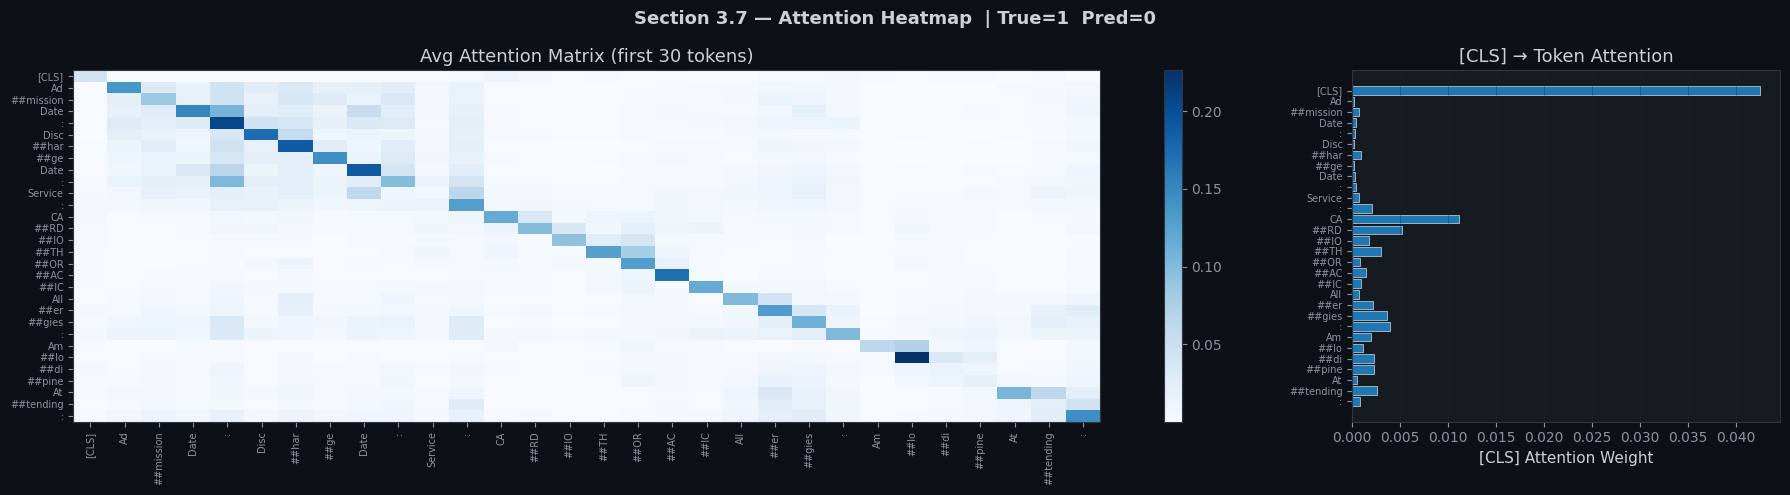

In [115]:
import numpy as np # Ensure numpy is imported for array operations

@torch.no_grad()
def get_attention_for_sample(model, text, tokenizer, device, max_len=128):
    """
    Run a forward pass with output_attentions=True and return:
      avg_attn   : (T, T) mean attention matrix over all heads (last layer)
      tokens     : list of token strings
      prediction : int (0 or 1)

    Works with the updated ClinicalBERTClassifier that returns
    ClassifierOutput(logits, attentions) — no return_dict kwarg needed.
    """
    # ── 1. Tokenize ──────────────────────────────────────────────────────────
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt",
    )
    input_ids      = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    token_type_ids = enc.get("token_type_ids", None)
    if token_type_ids is not None:
        token_type_ids = token_type_ids.to(device)

    # ── 2. Forward pass — output_attentions=True ─────────────────────────────
    # ClassifierOutput.attentions is a tuple of tensors: one per BERT layer
    # Each tensor shape: [batch, num_heads, seq_len, seq_len]
    outputs = model(
        input_ids         = input_ids,
        attention_mask    = attention_mask,
        token_type_ids    = token_type_ids,
        output_attentions = True,            # ← triggers attention return
        # return_dict NOT needed — our model always returns ClassifierOutput
    )

    # ── 3. Safety check ──────────────────────────────────────────────────────
    if outputs.attentions is None:
        raise ValueError(
            "Model returned no attentions. "
            "Ensure output_attentions=True is passed and the inner BERT supports it."
        )

    # ── 4. Last-layer attention ───────────────────────────────────────────────
    # outputs.attentions[-1] shape: [1, num_heads, seq_len, seq_len]
    last_layer_attn = outputs.attentions[-1].squeeze(0)   # [heads, T, T]

    # ── 5. Average over attention heads → [T, T] ─────────────────────────────
    avg_attn = last_layer_attn.mean(dim=0).cpu().numpy()  # [T, T]

    # ── 6. Decode tokens ─────────────────────────────────────────────────────
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))

    # ── 7. Prediction from logits ─────────────────────────────────────────────
    prediction = torch.argmax(outputs.logits, dim=-1).item()

    return avg_attn, tokens, prediction


# ── Select a high-risk test sample for ClinicalBERT ───────────────────────────
# The original code was using X_test (numerical array) and y_test (Series from sequence models),
# which are not appropriate for ClinicalBERT attention visualization.
# We need to select a text sample and its label from the ClinicalBERT processed data.

# Assuming 'df' here refers to the DataFrame used for ClinicalBERT,
# which has 'clean_text' and 'label' columns as prepared in Section 3.1.
high_risk_samples_df = df[df['label'] == 1]

if not high_risk_samples_df.empty:
    # Select the first high-risk sample for consistency, or a random one.
    # We need the original text and its label.
    sample_text_row = high_risk_samples_df.iloc[0]
    sample_text = sample_text_row['clean_text']
    sample_label = sample_text_row['label']
    sample_idx_original_df = sample_text_row.name # Store original index for info
else:
    # Fallback if no high-risk samples are found (should not happen with given data)
    print("[WARNING] No high-risk samples found in ClinicalBERT dataset. Using a random sample instead.")
    sample_text_row = df.iloc[0] # Take any sample
    sample_text = sample_text_row['clean_text']
    sample_label = sample_text_row['label']
    sample_idx_original_df = sample_text_row.name

print("[INFO] Selected sample index (from ClinicalBERT df):", sample_idx_original_df)
print("[INFO] True label:", sample_label)
print("[TEXT PREVIEW]")
print(sample_text[:200]) # Print first 200 characters of the selected text

# ── Run attention extraction ──────────────────────────────────────────────────
attn_matrix, tokens, prediction = get_attention_for_sample(
    model_s2, sample_text, tokenizer, device
)

print("\n[INFO] Prediction     :", prediction)
print("[INFO] Tokens length  :", len(tokens))
print("[INFO] Attention shape:", attn_matrix.shape)


# ── Visualise attention heatmap (CLS row, first 30 tokens) ───────────────────
def plot_attention_heatmap(attn_matrix, tokens, title="Attention Heatmap",
                           max_tokens=30, save_path=None):
    """
    Plot the [CLS] row of the average attention matrix.
    Shows how much attention the CLS token pays to each input token —
    a proxy for which clinical terms drove the prediction.
    """
    # Trim padding tokens
    real_len  = min(max_tokens, next(
        (i for i, t in enumerate(tokens) if t == "[PAD]"), len(tokens)
    ))
    trimmed_tokens = tokens[:real_len]
    cls_attn       = attn_matrix[0, :real_len]   # [CLS] row, real tokens only

    fig, axes = plt.subplots(1, 2, figsize=(18, 5),
                              gridspec_kw={"width_ratios": [3, 1]})
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # ── Left: full attention sub-matrix ──────────────────────────────────────
    im = axes[0].imshow(attn_matrix[:real_len, :real_len],
                        cmap="Blues", aspect="auto")
    axes[0].set_xticks(range(real_len))
    axes[0].set_yticks(range(real_len))
    axes[0].set_xticklabels(trimmed_tokens, rotation=90, fontsize=7)
    axes[0].set_yticklabels(trimmed_tokens, fontsize=7)
    axes[0].set_title(f"Avg Attention Matrix (first {real_len} tokens)")
    plt.colorbar(im, ax=axes[0])

    # ── Right: CLS attention bar chart ───────────────────────────────────────
    y_pos = range(real_len)
    axes[1].barh(y_pos, cls_attn, color="#1F77B4", edgecolor="white", linewidth=0.4)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(trimmed_tokens, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("[CLS] Attention Weight")
    axes[1].set_title("[CLS] → Token Attention")
    axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[3.7] Saved → {save_path}")
    plt.show()


ATTN_SAVE = ("/content/drive/MyDrive/Intelligent Clinical Early Warning System"
             "/results/gen3_attention_heatmap.png")

plot_attention_heatmap(
    attn_matrix, tokens,
    title=f"Section 3.7 — Attention Heatmap  "
          f"| True={sample_label}  Pred={prediction}",
    max_tokens=30,
    save_path=ATTN_SAVE,
)

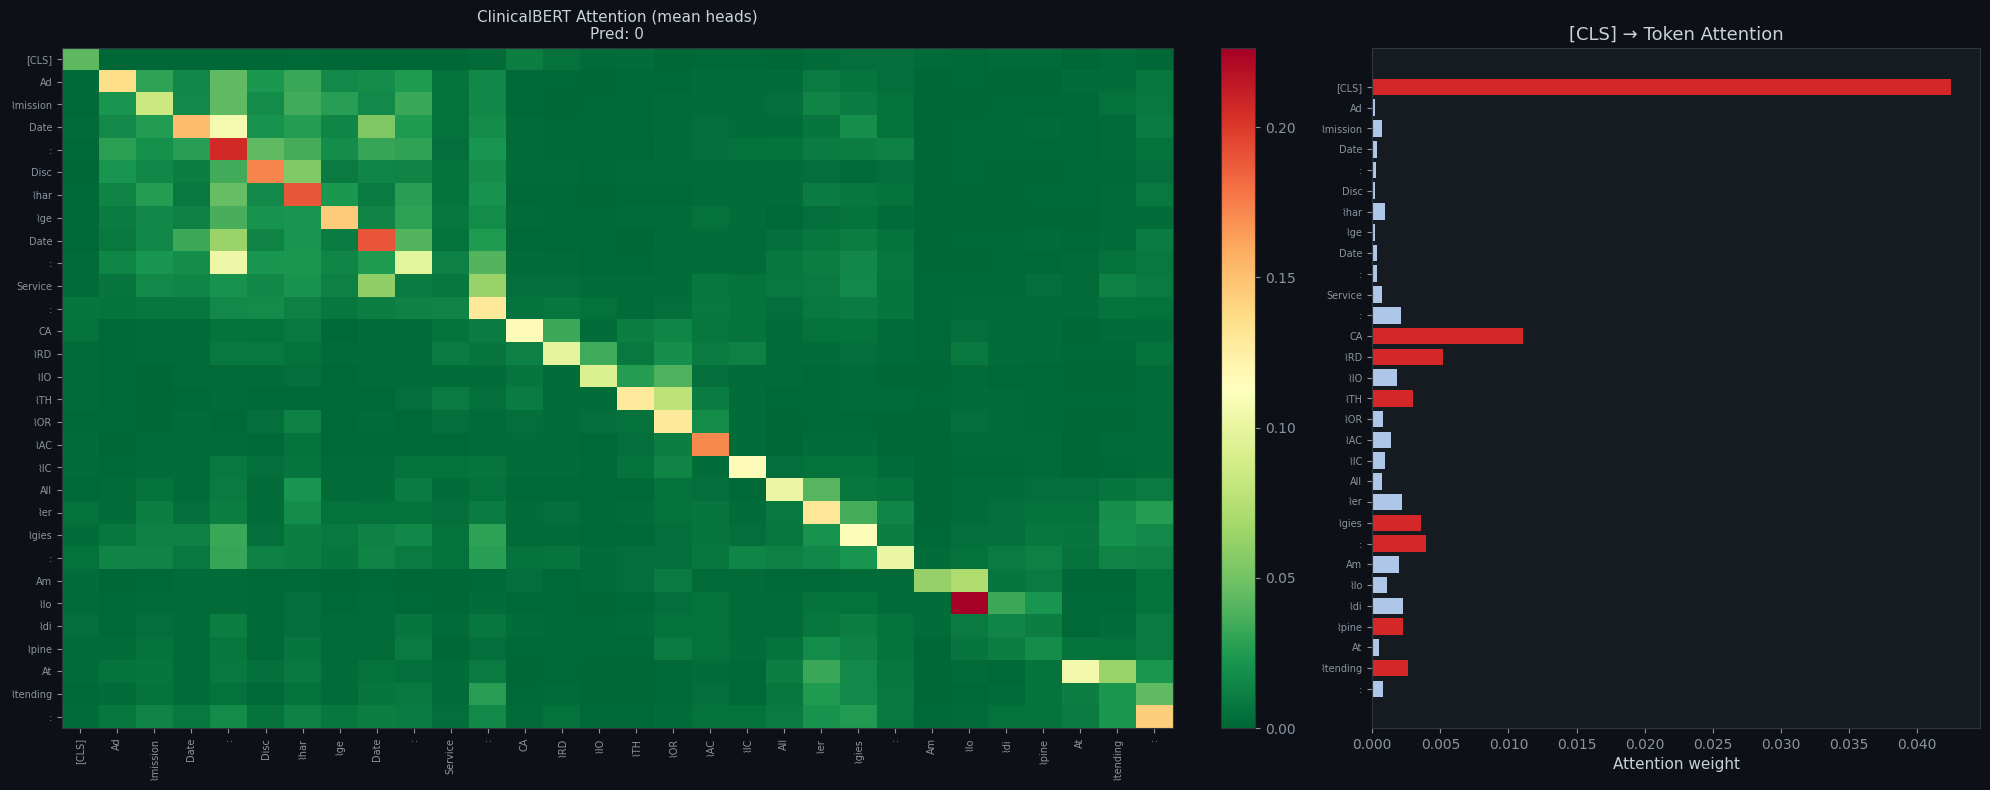

In [116]:
SHOW = min(30, len(tokens))

attn_show = attn_matrix[:SHOW, :SHOW]
tokens_show = tokens[:SHOW]

disp_tokens = [t.replace("##", "⌇") for t in tokens_show]

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 8),
    gridspec_kw={"width_ratios": [2, 1]}
)

# =========================
# HEATMAP
# =========================
im = axes[0].imshow(attn_show, cmap="RdYlGn_r", aspect="auto", vmin=0)

axes[0].set_xticks(range(SHOW))
axes[0].set_yticks(range(SHOW))
axes[0].set_xticklabels(disp_tokens, rotation=90, fontsize=7)
axes[0].set_yticklabels(disp_tokens, fontsize=7)

axes[0].set_title(
    f"ClinicalBERT Attention (mean heads)\n"
    f"Pred: {prediction}",
    fontsize=11
)

plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# =========================
# CLS ATTENTION BAR
# =========================
cls_attn = attn_show[0]

colors = [
    "#d62728" if w > np.percentile(cls_attn, 75) else "#aec7e8"
    for w in cls_attn
]

axes[1].barh(range(SHOW), cls_attn[::-1], color=colors[::-1])
axes[1].set_yticks(range(SHOW))
axes[1].set_yticklabels(disp_tokens[::-1], fontsize=7)

axes[1].set_title("[CLS] → Token Attention")
axes[1].set_xlabel("Attention weight")

plt.tight_layout()
plt.show()

In [117]:
top5_idx = np.argsort(cls_attn)[-5:][::-1]

print("[TOP 5 IMPORTANT TOKENS]")
for i, ti in enumerate(top5_idx, 1):
    print(f"{i}. {tokens_show[ti]}  | weight={cls_attn[ti]:.4f}")

[TOP 5 IMPORTANT TOKENS]
1. [CLS]  | weight=0.0425
2. CA  | weight=0.0111
3. ##RD  | weight=0.0052
4. :  | weight=0.0039
5. ##gies  | weight=0.0036





<h1 style="color: skyblue;">SECTION — 3.8 ClinicalBERT Evaluation</h1>

<b style="color: Aqua;">Metrics:</b>

<p style="color: lightblue;">- Accuracy
- Precision
- Recall
- F1-score</p>



In [118]:
def full_evaluation(model: nn.Module, loader: DataLoader,
                    strategy_name: str) -> Tuple[List[int], List[int]]:
    _, _, preds, labels = evaluate(model, loader)

    acc = accuracy_score(labels, preds)
    pr  = precision_score(labels, preds, average="weighted", zero_division=0)
    rc  = recall_score   (labels, preds, average="weighted", zero_division=0)
    f1  = f1_score       (labels, preds, average="weighted", zero_division=0)

    print(f"\n  [{strategy_name}]  TEST SET METRICS")
    print(f"  {'Accuracy' :<16}: {acc:.4f}")
    print(f"  {'Precision':<16}: {pr:.4f}")
    print(f"  {'Recall'   :<16}: {rc:.4f}")
    print(f"  {'F1-score' :<16}: {f1:.4f}")
    return preds, labels


preds_s1, labels_s1 = full_evaluation(model_s1, test_dl, "Strategy-1 Frozen")
preds_s2, labels_s2 = full_evaluation(model_s2, test_dl, "Strategy-2 Full-FT")


  [Strategy-1 Frozen]  TEST SET METRICS
  Accuracy        : 0.6044
  Precision       : 0.6034
  Recall          : 0.6044
  F1-score        : 0.5942

  [Strategy-2 Full-FT]  TEST SET METRICS
  Accuracy        : 0.6178
  Precision       : 0.6167
  Recall          : 0.6178
  F1-score        : 0.6169


In [119]:
# ── summary table ─────────────────────────────────────────────────────────────
def metrics_dict(y_true, y_pred, name):
    return {
        "Strategy"  : name,
        "Accuracy"  : round(accuracy_score(y_true, y_pred), 4),
        "Precision" : round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Recall"    : round(recall_score   (y_true, y_pred, average="weighted", zero_division=0), 4),
        "F1-Score"  : round(f1_score       (y_true, y_pred, average="weighted", zero_division=0), 4),
    }

metrics_table = pd.DataFrame([
    metrics_dict(labels_s1, preds_s1, "Strategy-1 (Frozen)"),
    metrics_dict(labels_s2, preds_s2, "Strategy-2 (Full-FT)"),
])
print(f"\n{'─'*60}")
print(metrics_table.to_string(index=False))
print(f"{'─'*60}\n")


────────────────────────────────────────────────────────────
            Strategy  Accuracy  Precision  Recall  F1-Score
 Strategy-1 (Frozen)    0.6044     0.6034  0.6044    0.5942
Strategy-2 (Full-FT)    0.6178     0.6167  0.6178    0.6169
────────────────────────────────────────────────────────────



In [120]:
# ── confusion-matrix plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Section 3.8 — Confusion Matrices (Test Set)", fontsize=13)

for ax, preds, labels, name, cmap in zip(
        axes,
        [preds_s1, preds_s2],
        [labels_s1, labels_s2],
        ["Strategy-1 (Frozen Base)", "Strategy-2 (Full Fine-Tune)"],
        ["Blues", "Oranges"]):
    cm    = confusion_matrix(labels, preds)
    cm_df = pd.DataFrame(cm,
                         index  =["True: Stable", "True: High-risk"],
                         columns=["Pred: Stable", "Pred: High-risk"])
    sns.heatmap(cm_df, annot=True, fmt="d", cmap=cmap, ax=ax,
                linewidths=0.5, linecolor="grey",
                annot_kws={"size":13})
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
fig.savefig(os.path.join(str(OUTPUT_DIR), "gen3_confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.close()
print("/content/drive/Othercomputers/My Laptop (1)/DL Complex Computing Problem/results/gen3_confusion_matrices.png")

/content/drive/Othercomputers/My Laptop (1)/DL Complex Computing Problem/results/gen3_confusion_matrices.png



<h1 style="color: skyblue;">SECTION — 3.9 Per-Class Performance Breakdown</h1>

In [121]:
import textwrap
TARGET_NAMES = ["Stable (0)", "High-risk (1)"]

print("\n  [Strategy-1 Frozen] Classification Report:")
rep_s1 = classification_report(
    labels_s1, preds_s1, target_names=TARGET_NAMES, zero_division=0
)
print(textwrap.indent(rep_s1, "    "))

print("\n  [Strategy-2 Full Fine-Tune] Classification Report:")
rep_s2 = classification_report(
    labels_s2, preds_s2, target_names=TARGET_NAMES, zero_division=0
)
print(textwrap.indent(rep_s2, "    "))


  [Strategy-1 Frozen] Classification Report:
                   precision    recall  f1-score   support

       Stable (0)       0.61      0.75      0.67       242
    High-risk (1)       0.60      0.44      0.51       208

         accuracy                           0.60       450
        macro avg       0.60      0.59      0.59       450
     weighted avg       0.60      0.60      0.59       450


  [Strategy-2 Full Fine-Tune] Classification Report:
                   precision    recall  f1-score   support

       Stable (0)       0.64      0.67      0.65       242
    High-risk (1)       0.59      0.56      0.58       208

         accuracy                           0.62       450
        macro avg       0.61      0.61      0.61       450
     weighted avg       0.62      0.62      0.62       450



In [122]:
# ── per-class bar chart ───────────────────────────────────────────────────────
def per_class_metrics(y_true, y_pred):
    rows = []
    for cls_idx, cls_name in enumerate(TARGET_NAMES):
        rows.append({
            "Class"    : cls_name,
            "Precision": precision_score(y_true, y_pred, labels=[cls_idx],
                                         average="macro", zero_division=0),
            "Recall"   : recall_score   (y_true, y_pred, labels=[cls_idx],
                                         average="macro", zero_division=0),
            "F1"       : f1_score       (y_true, y_pred, labels=[cls_idx],
                                         average="macro", zero_division=0),
        })
    return pd.DataFrame(rows)


pc_s1 = per_class_metrics(labels_s1, preds_s1)
pc_s2 = per_class_metrics(labels_s2, preds_s2)


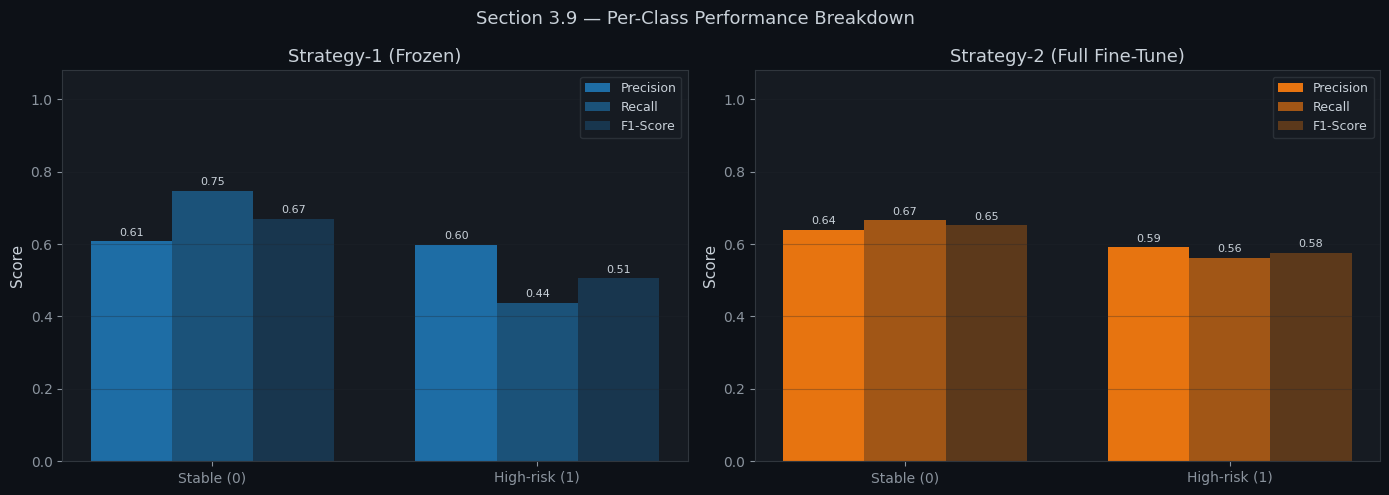

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Section 3.9 — Per-Class Performance Breakdown", fontsize=13)

for ax, pc, name, colour in zip(
        axes,
        [pc_s1, pc_s2],
        ["Strategy-1 (Frozen)", "Strategy-2 (Full Fine-Tune)"],
        ["#1F77B4", "#FF7F0E"]):
    x      = np.arange(len(TARGET_NAMES))
    width  = 0.25
    bars_p = ax.bar(x - width,   pc["Precision"], width, label="Precision",
                    color=colour, alpha=0.9)
    bars_r = ax.bar(x,           pc["Recall"],    width, label="Recall",
                    color=colour, alpha=0.6)
    bars_f = ax.bar(x + width,   pc["F1"],        width, label="F1-Score",
                    color=colour, alpha=0.3)

    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_NAMES)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

    for bar_grp in [bars_p, bars_r, bars_f]:
        for bar in bar_grp:
            ax.text(bar.get_x() + bar.get_width() / 2.,
                    bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()
fig.savefig( "/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/gen3_perclass_breakdown.png", dpi=150, bbox_inches="tight")
plt.close()

In [124]:
print("=" * 70)
print("GENERATION 3 COMPLETE — Summary")
print("=" * 70)
print(f"  Model            : {MODEL_NAME}")
print(f"  MAX_LEN          : {MAX_LEN}")
print(f"  Sample size      : {SAMPLE_N:,}")
print()
print(comparison_df.to_string(index=False))
print()
print("  Output artefacts:")
import glob as _glob
OUTPUT_DIR='/content/drive/Othercomputers/My Laptop (1)/DL Complex Computing Problem/results'
for f in sorted(_glob.glob(os.path.join(str(OUTPUT_DIR), "gen3_*.png"))):
    print(f"    ✓  {f}")
print()
print("[GEN-3]  All sections complete.")

GENERATION 3 COMPLETE — Summary
  Model            : emilyalsentzer/Bio_ClinicalBERT
  MAX_LEN          : 128
  Sample size      : 3,000

                   Strategy  Trainable Params  Total Params  Wall-Clock (s)  Final Val Acc  Final Val Loss
   Strategy-1 (Frozen Base)            197378     108507650            52.1         0.6266          0.6563
Strategy-2 (Full Fine-Tune)         108507650     108507650            97.6         0.6449          0.6457

  Output artefacts:

[GEN-3]  All sections complete.




<h1 style="color: skyblue;">UNIFIED MODEL RESULTS</h1>
<p style="color: lightblue;">


<b style="color: Aqua;">Include:</b>

<p style="color: lightblue;">
DNN,
LSTM,
GRU,
Bi-LSTM,
ClinicalBERT Frozen,
ClinicalBERT Full FT</p>





In [126]:
results = []

def add_result(model_name, y_true, y_pred, training_time):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "Training Time": training_time
    })

# --- DNN (Baseline) ---
# X_test, y_test from Section 1.1
# best_optimizer, trained_models, training_times from Section 1.3
# Note: The threshold for DNN was implicitly 0.5 in the evaluation `waBveLtrVUW3`
dnn_model = trained_models[best_optimizer]
dnn_preds = (dnn_model.predict(X_test, verbose=0) > 0.5).astype(int)
# Corrected: Get DNN training time from the 'best_dnn' Series
dnn_training_time = best_dnn["Training Time (s)"]
add_result("DNN (Baseline)", y_test, dnn_preds, dnn_training_time)

# --- LSTM, GRU, Bi-LSTM ---
# y_te is the true labels for the sequence models from Section 2.1
# test_results and training_times are from Section 2.8 and 2.6 respectively
# THRESHOLD from Section 2.4
lstm_preds = (test_results['LSTM']['y_prob'] >= THRESHOLD).astype(int)
lstm_training_time = training_times['LSTM']
add_result("LSTM", y_te, lstm_preds, lstm_training_time)

gru_preds = (test_results['GRU']['y_prob'] >= THRESHOLD).astype(int)
gru_training_time = training_times['GRU']
add_result("GRU", y_te, gru_preds, gru_training_time)

bilstm_preds = (test_results['BiLSTM']['y_prob'] >= THRESHOLD).astype(int)
bilstm_training_time = training_times['BiLSTM']
add_result("Bi-LSTM", y_te, bilstm_preds, bilstm_training_time)

# --- ClinicalBERT (Frozen) ---
# preds_s1, labels_s1, time_s1 are from Section 3.4
add_result("ClinicalBERT (Frozen)", labels_s1, preds_s1, time_s1)

# --- ClinicalBERT (Full Fine-tune) ---
# preds_s2, labels_s2, time_s2 are from Section 3.5
add_result("ClinicalBERT (Full Fine-tune)", labels_s2, preds_s2, time_s2)

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,Training Time
0,DNN (Baseline),0.703680,0.705938,0.703680,0.702864,10.652791
1,LSTM,0.602173,0.972304,0.602173,0.734757,148.756960
2,GRU,0.327556,0.976381,0.327556,0.472040,141.476708
3,Bi-LSTM,0.334595,0.975700,0.334595,0.480310,250.085138
4,ClinicalBERT (Frozen),0.604444,0.603362,0.604444,0.594189,52.090495
5,ClinicalBERT (Full Fine-tune),0.617778,0.616712,0.617778,0.616939,97.641268


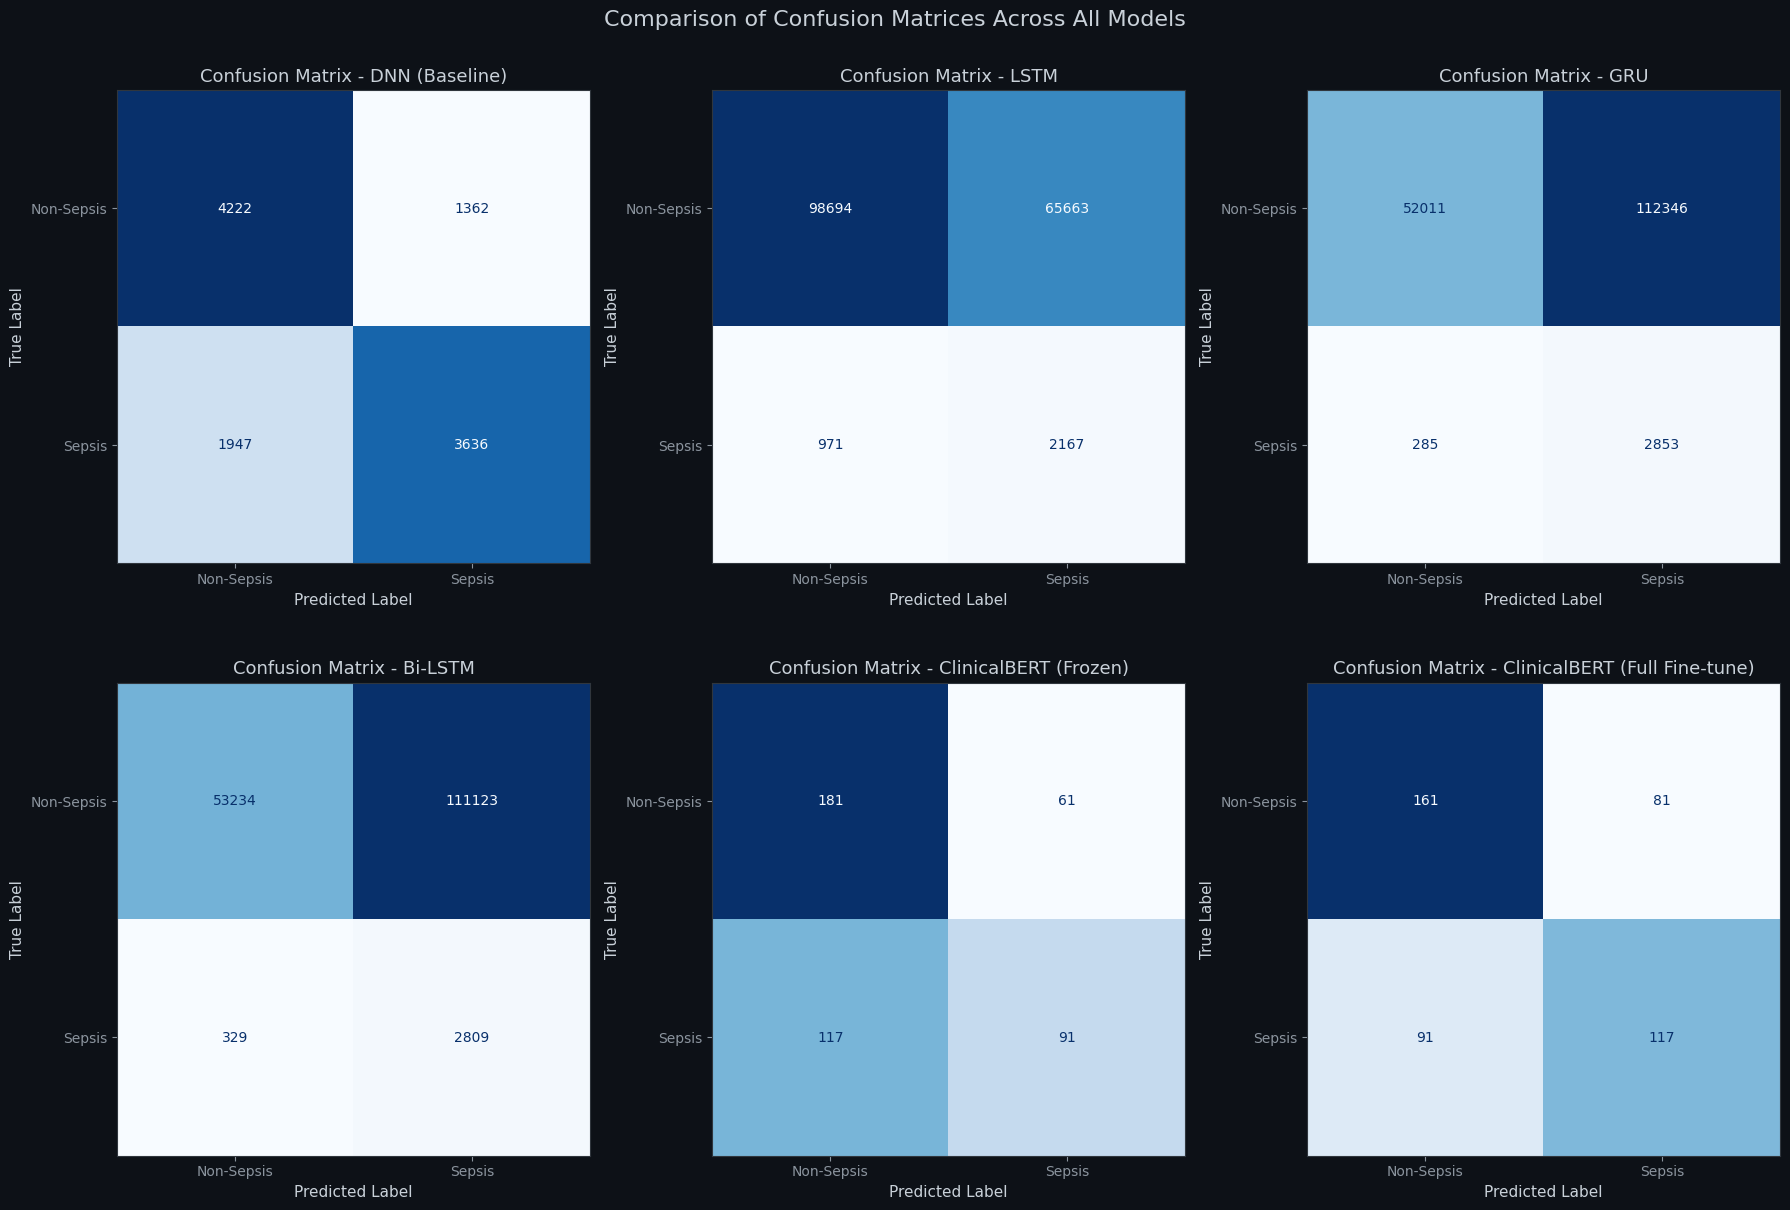

In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prepare data for all models
models_to_plot = [
    {"name": "DNN (Baseline)", "y_true": y_test, "y_pred": dnn_preds.ravel()},
    {"name": "LSTM", "y_true": test_results['LSTM']['y_true'], "y_pred": (test_results['LSTM']['y_prob'] >= THRESHOLD).astype(int)},
    {"name": "GRU", "y_true": test_results['GRU']['y_true'], "y_pred": (test_results['GRU']['y_prob'] >= THRESHOLD).astype(int)},
    {"name": "Bi-LSTM", "y_true": test_results['BiLSTM']['y_true'], "y_pred": (test_results['BiLSTM']['y_prob'] >= THRESHOLD).astype(int)},
    {"name": "ClinicalBERT (Frozen)", "y_true": labels_s1, "y_pred": preds_s1},
    {"name": "ClinicalBERT (Full Fine-tune)", "y_true": labels_s2, "y_pred": preds_s2}
]

# Create a figure with 2 rows and 3 columns for 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 array of axes for easier iteration

for i, model_data in enumerate(models_to_plot):
    cm = confusion_matrix(model_data["y_true"], model_data["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Sepsis', 'Sepsis'])

    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f"Confusion Matrix - {model_data['name']}")
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.suptitle('Comparison of Confusion Matrices Across All Models', y=1.02, fontsize=16)
plt.savefig('/content/drive/MyDrive/Intelligent Clinical Early Warning System/results/confusion_metrics_of_all_models.png')
plt.show()

## Save All Models

In [135]:
import os
import torch
import tensorflow as tf
from pathlib import Path

# Define the base directory for saving models
MODELS_DIR = Path('/content/drive/MyDrive/Intelligent Clinical Early Warning System/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True) # Ensure the directory exists

print(f"Saving models to: {MODELS_DIR}\n")

# --- Save DNN (TensorFlow/Keras) models ---
# The `trained_models` dictionary contains the Keras DNN models from Generation 1
for name, model in trained_models.items():
    dnn_save_path = MODELS_DIR / f'gen1_dnn_{name.lower()}.keras'
    try:
        model.save(dnn_save_path)
        print(f"  [✓] Saved DNN ({name}): {dnn_save_path.name}")
    except Exception as e:
        print(f"  [✗] Error saving DNN ({name}): {e}")

# --- Save PyTorch RNN/LSTM models ---
# The `models` dictionary contains the PyTorch LSTM, GRU, BiLSTM models from Generation 2
for name, model in models.items():
    pt_rnn_save_path = MODELS_DIR / f'gen2_{name.lower()}.pt'
    try:
        torch.save(model.state_dict(), pt_rnn_save_path)
        print(f"  [✓] Saved PyTorch RNN ({name}): {pt_rnn_save_path.name}")
    except Exception as e:
        print(f"  [✗] Error saving PyTorch RNN ({name}): {e}")

# --- Save PyTorch ClinicalBERT models ---
# `model_s1` and `model_s2` are the ClinicalBERT models from Generation 3
# ClinicalBERT (Frozen)
clinicalbert_frozen_save_path = MODELS_DIR / 'gen3_clinicalbert_frozen.pt'
try:
    torch.save(model_s1.state_dict(), clinicalbert_frozen_save_path)
    print(f"  [✓] Saved ClinicalBERT (Frozen): {clinicalbert_frozen_save_path.name}")
except Exception as e:
    print(f"  [✗] Error saving ClinicalBERT (Frozen): {e}")

# ClinicalBERT (Full Fine-tune)
clinicalbert_full_ft_save_path = MODELS_DIR / 'gen3_clinicalbert_full_finetune.pt'
try:
    torch.save(model_s2.state_dict(), clinicalbert_full_ft_save_path)
    print(f"  [✓] Saved ClinicalBERT (Full Fine-tune): {clinicalbert_full_ft_save_path.name}")
except Exception as e:
    print(f"  [✗] Error saving ClinicalBERT (Full Fine-tune): {e}")

print("\n✅ All specified models saved successfully.")

Saving models to: /content/drive/MyDrive/Intelligent Clinical Early Warning System/models

  [✓] Saved DNN (Adam): gen1_dnn_adam.keras
  [✓] Saved DNN (SGD): gen1_dnn_sgd.keras
  [✓] Saved PyTorch RNN (LSTM): gen2_lstm.pt
  [✓] Saved PyTorch RNN (GRU): gen2_gru.pt
  [✓] Saved PyTorch RNN (BiLSTM): gen2_bilstm.pt
  [✓] Saved ClinicalBERT (Frozen): gen3_clinicalbert_frozen.pt
  [✓] Saved ClinicalBERT (Full Fine-tune): gen3_clinicalbert_full_finetune.pt

✅ All specified models saved successfully.
